# Regression Track: Predicting Concrete Compressive Strength

**Problem.** Given a concrete mix (cement, blast-furnace slag, fly ash, water, superplasticiser, coarse and fine aggregate) and curing age, predict compressive strength in MPa. Strength depends on the ingredients non-linearly, so it's a good dataset for comparing linear, regularised, tree-based, kernel and distance-based models side by side.

**Dataset.** `data/data.csv`: 1030 samples, 8 measured inputs, 5 derived columns, and the target.

| Column | Meaning | Unit |
|---|---|---|
| `cement`, `slag`, `ash` | binder ingredients (Portland cement, blast-furnace slag, fly ash) | kg/m³ |
| `water`, `superplastic` | mixing water, superplasticiser | kg/m³ |
| `coarseagg`, `fineagg` | coarse and fine aggregate | kg/m³ |
| `age` | curing age | days |
| `water_cement_ratio`, `total_binder`, `aggregate_to_cement`, `cement_water_interaction`, `age_strength_proxy` | derived columns already present in the file (audited for leakage in section 3) | mixed |
| **`strength`** | compressive strength, the **target** | MPa |


---
# 1. Setup and data loading

In [1]:
import os
import warnings

# Cap BLAS thread pools BEFORE importing numpy/sklearn: with GridSearchCV's own
# multiprocessing (n_jobs), letting each worker ALSO spawn multiple BLAS threads
# oversubscribes the CPU and can exhaust memory (OpenBLAS allocation errors / kernel crashes).
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

# Very small alphas in the Lasso/ElasticNet grids raise ConvergenceWarning in some folds.
# Those settings simply score badly and are not selected, so the warnings are silenced
# (the env var covers the joblib worker processes, the filter covers this process).
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold, cross_val_score, learning_curve,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import sklearn

# ---------------------------------------------------------------- global config
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_FOLDS      = 5
np.random.seed(RANDOM_STATE)

# Plot style: colourblind-safe palette, and automatic layout so labels are never clipped.
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "data/data.csv"
TARGET = "strength"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1030 rows x 14 columns


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_binder,aggregate_to_cement,cement_water_interaction,age_strength_proxy
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89,1.440188,353.3,12.174719,28754.55,5.291503
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51,0.937235,335.4,11.113019,26736.87,3.741657
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22,0.749597,345.7,7.272371,46850.00,5.291503
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857140,380.0,6.022534,60648.00,5.291503
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29,1.248700,338.2,11.266723,29922.84,5.291503


---
# 2. Exploratory data analysis

## 2.1 Structure, missing values and duplicates

In [2]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cement                    1030 non-null   float64
 1   slag                      1030 non-null   float64
 2   ash                       1030 non-null   float64
 3   water                     1030 non-null   float64
 4   superplastic              1030 non-null   float64
 5   coarseagg                 1030 non-null   float64
 6   fineagg                   1030 non-null   float64
 7   age                       1030 non-null   int64  
 8   strength                  1030 non-null   float64
 9   water_cement_ratio        1030 non-null   float64
 10  total_binder              1030 non-null   float64
 11  aggregate_to_cement       1030 non-null   float64
 12  cement_water_interaction  1030 non-null   float64
 13  age_strength_proxy        1030 non-null   float64
dtypes: float64(13), int

In [3]:


missing = pd.DataFrame({"n_missing": df.isna().sum(),"pct_missing": (df.isna().mean()*100).round(2),})
print("Missing values per column:")
print(missing.to_string())
n_dup = df.duplicated().sum()
pct_dup = (n_dup / len(df)) * 100
print(f"\nFully duplicated rows: {n_dup}  ({pct_dup:.2f}% of the data)")

Missing values per column:
                          n_missing  pct_missing
cement                            0          0.0
slag                              0          0.0
ash                               0          0.0
water                             0          0.0
superplastic                      0          0.0
coarseagg                         0          0.0
fineagg                           0          0.0
age                               0          0.0
strength                          0          0.0
water_cement_ratio                0          0.0
total_binder                      0          0.0
aggregate_to_cement               0          0.0
cement_water_interaction          0          0.0
age_strength_proxy                0          0.0

Fully duplicated rows: 25  (2.43% of the data)


In [4]:

desc = df.describe().T
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
cement,1030.0,281.168,104.506,102.000,192.375,272.900,350.000,540.000,0.509,-0.521
slag,1030.0,73.896,86.279,0.000,0.000,22.000,142.950,359.400,0.801,-0.508
ash,1030.0,54.188,63.997,0.000,0.000,0.000,118.300,200.100,0.537,-1.329
water,1030.0,181.567,21.354,121.800,164.900,185.000,192.000,247.000,0.075,0.122
superplastic,1030.0,6.205,5.974,0.000,0.000,6.400,10.200,32.200,0.907,1.411
coarseagg,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000,-0.040,-0.599
fineagg,1030.0,773.580,80.176,594.000,730.950,779.500,824.000,992.600,-0.253,-0.102
age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000,3.269,12.169
strength,1030.0,35.818,16.706,2.330,23.710,34.445,46.135,82.600,0.417,-0.314
water_cement_ratio,1030.0,0.748,0.314,0.267,0.533,0.675,0.935,1.882,0.958,0.734


## 2.2 Target variable: distribution of `strength`

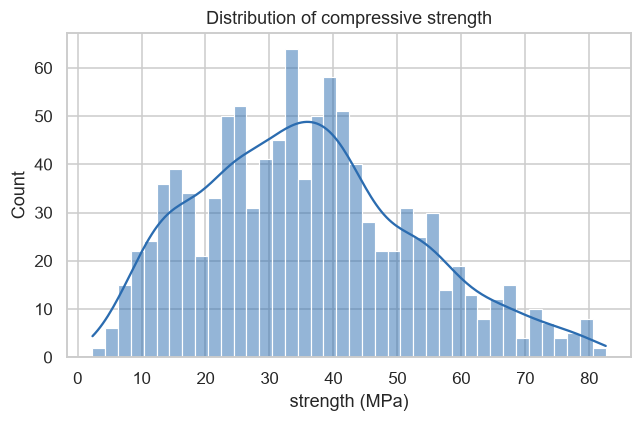

In [5]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET], bins=40, kde=True, color="#2b6cb0")
plt.title("Distribution of compressive strength")
plt.xlabel("strength (MPa)")
plt.ylabel("Count")
plt.show()

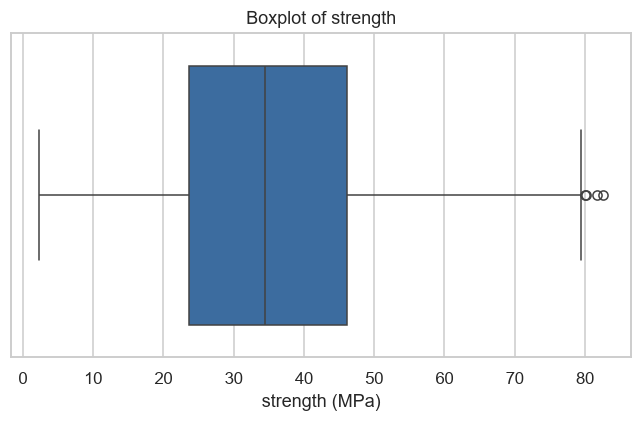

In [6]:

plt.figure(figsize=(6, 4))
sns.boxplot(x=df[TARGET], color="#2b6cb0")
plt.title("Boxplot of strength")
plt.xlabel("strength (MPa)")
plt.show()

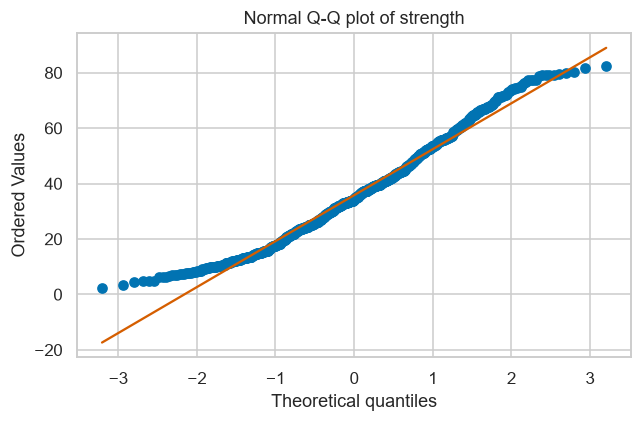

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
plt.figure(figsize=(6, 4))
ax = plt.gca()
stats.probplot(df[TARGET], dist="norm", plot=ax)
plt.title("Normal Q-Q plot of strength")
plt.show()

In [8]:
print(f"mean   : {df[TARGET].mean():.2f} MPa")
print(f"median : {df[TARGET].median():.2f} MPa")
print(f"std    : {df[TARGET].std():.2f} MPa")
print(f"min    : {df[TARGET].min():.2f} MPa")
print(f"max    : {df[TARGET].max():.2f} MPa")
print(f"skew   : {df[TARGET].skew():.3f}")

mean   : 35.82 MPa
median : 34.45 MPa
std    : 16.71 MPa
min    : 2.33 MPa
max    : 82.60 MPa
skew   : 0.417


**Observation (target).** Strength is close to normal, just a little right skewed (skew 0.417), and the mean (35.82) sitting a bit above the median (34.45) matches that. The boxplot has a few points above the top whisker but nothing at the bottom, and the Q-Q plot tracks the line okay through the middle then drifts off at the top tail. Skew this small probably isn't worth transforming, so we left the target alone.

## 2.3 Distribution of every predictor

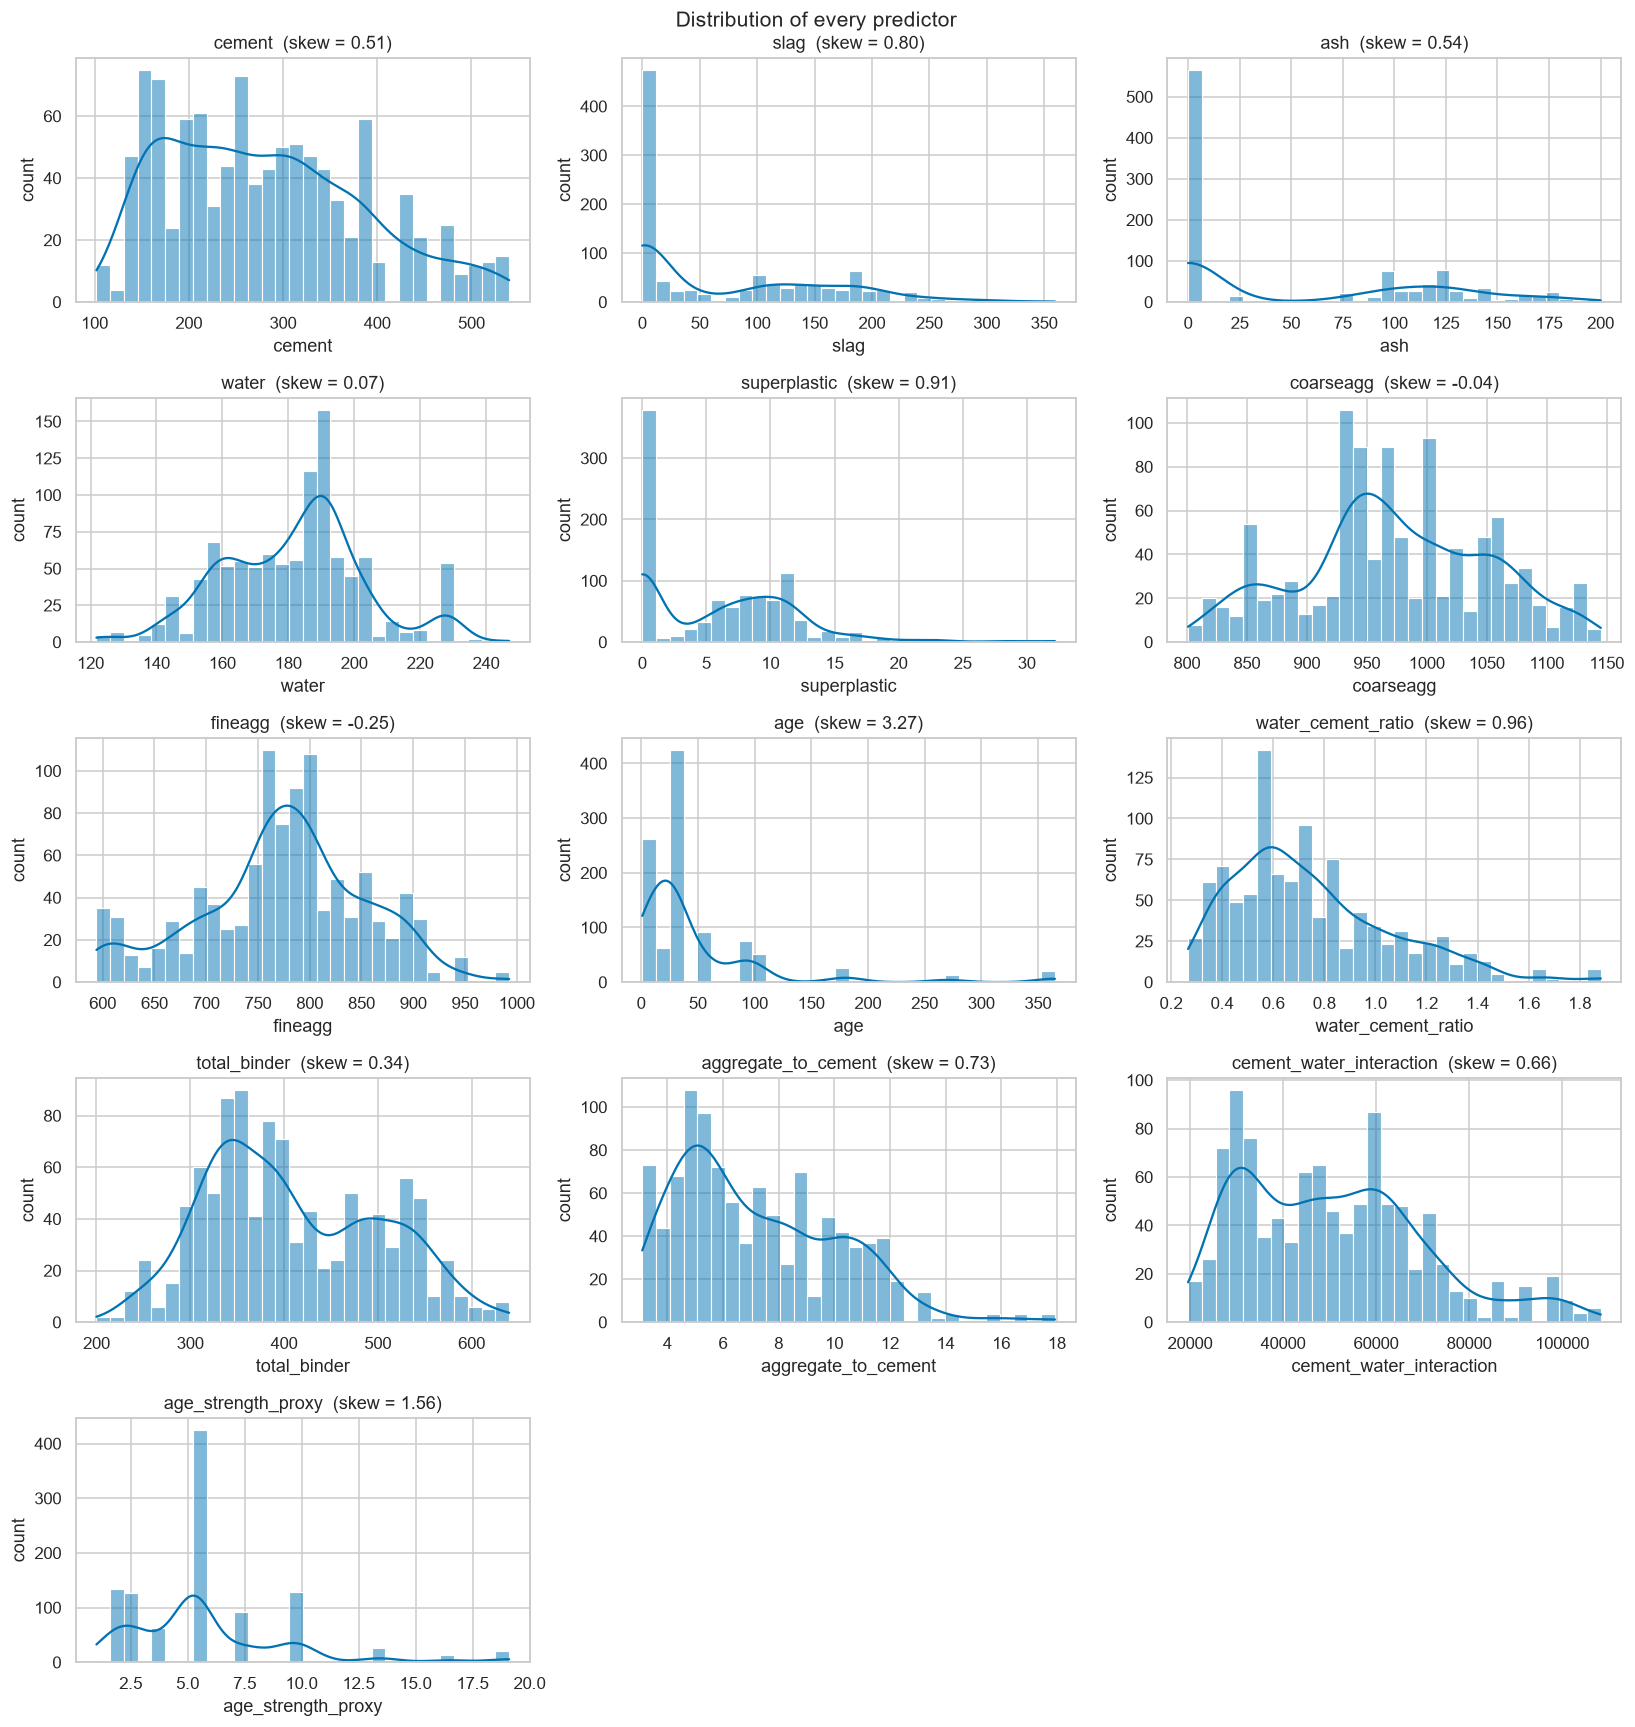

Share of rows where the feature is exactly 0 (%):
ash             55.0
slag            45.7
superplastic    36.8


In [9]:
features = [c for c in df.columns if c != TARGET]

fig, axes = plt.subplots(5, 3, figsize=(15, 16))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
for ax in axes.ravel()[len(features):]:
    ax.axis("off")
fig.suptitle("Distribution of every predictor", fontsize=14)
plt.show()

# Some ingredients are simply absent from many mixes (a genuine zero, not a missing value).
zero_share = (df[features] == 0).mean().mul(100).round(1)
print("Share of rows where the feature is exactly 0 (%):")
print(zero_share[zero_share > 0].sort_values(ascending=False).to_string())

**Observation (feature distributions).** Most features are skewed, age especially (the skew value is in each subplot title). The zero counts are the bigger thing though: ash is 0 in 55% of mixes, slag in 45.7%, superplastic in 36.8%. These aren't missing, some mixes genuinely don't use that ingredient, so there's nothing to impute there. The features are also on completely different scales (kg/m³ vs days vs the ratio columns), which is why everything gets standardised before it hits a model, and age gets log1p'd on top of that since it's the worst offender.

## 2.4 Correlations

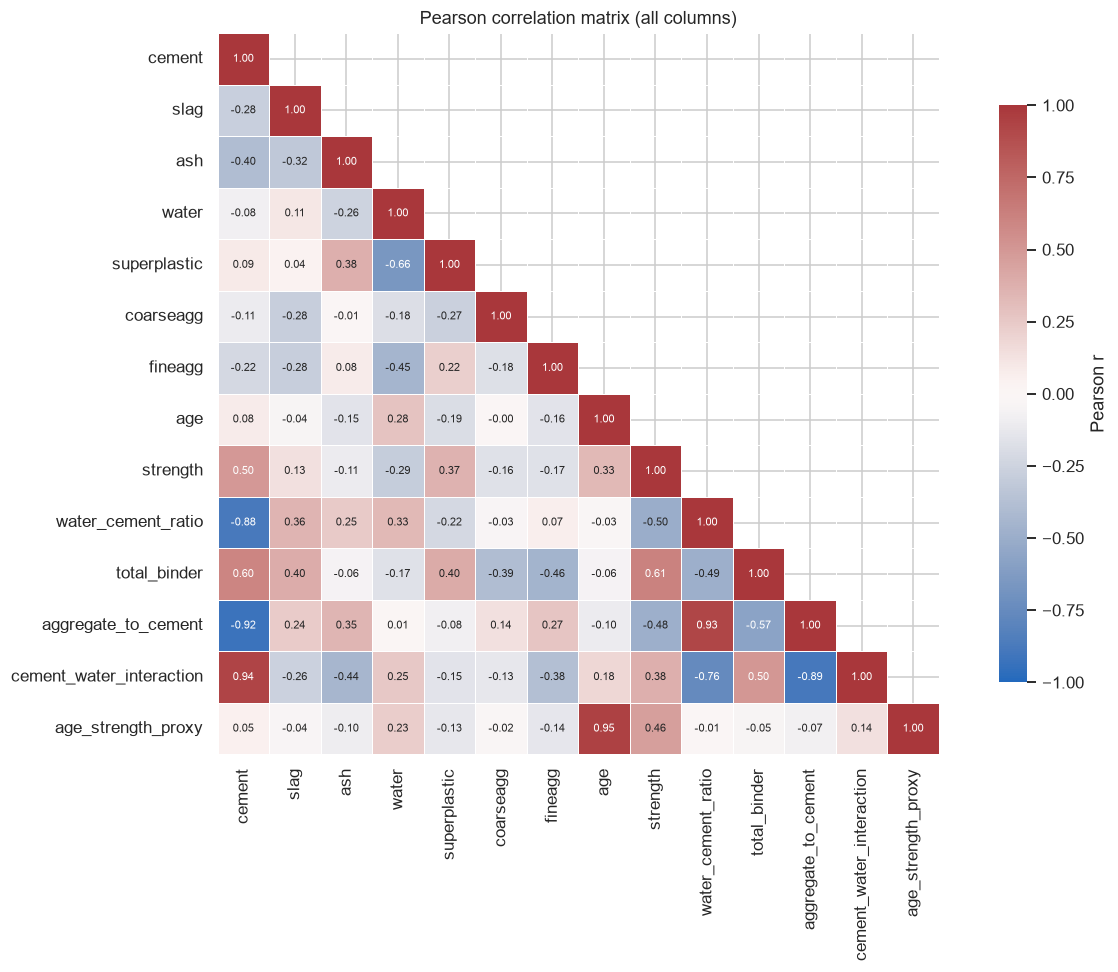

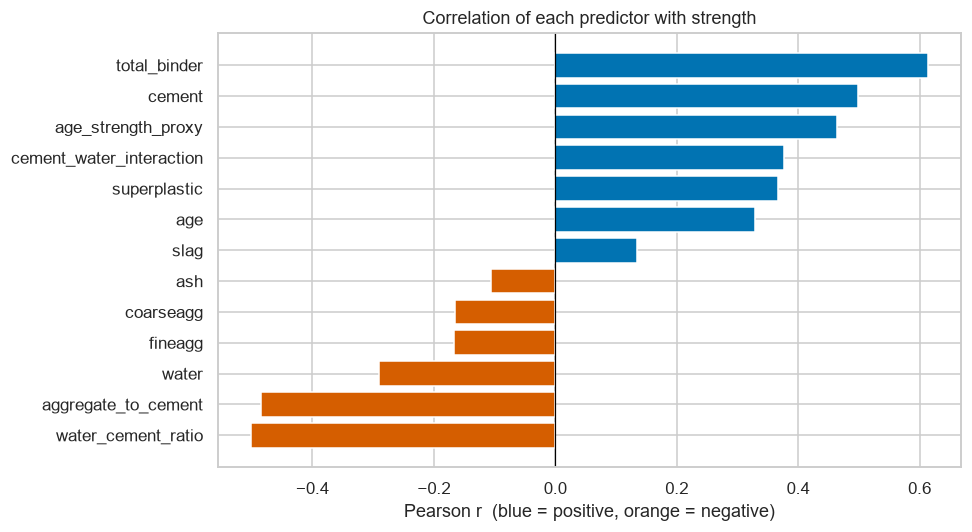

water_cement_ratio         -0.501
aggregate_to_cement        -0.484
water                      -0.290
fineagg                    -0.167
coarseagg                  -0.165
ash                        -0.106
slag                        0.135
age                         0.329
superplastic                0.366
cement_water_interaction    0.376
age_strength_proxy          0.464
cement                      0.498
total_binder                0.613


In [10]:
corr = df.corr(numeric_only=True)

# Lower triangle only, so each pair appears once.
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r", "shrink": .8}, ax=ax)
ax.set_title("Pearson correlation matrix (all columns)")
plt.show()

# Correlation of each predictor with the target.
target_corr = corr[TARGET].drop(TARGET).sort_values()
bar_colors = ["#D55E00" if v < 0 else "#0173B2" for v in target_corr]   # colourblind-safe pair

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(target_corr.index, target_corr.values, color=bar_colors)
ax.axvline(0, color="black", lw=.8)
ax.set_title("Correlation of each predictor with strength")
ax.set_xlabel("Pearson r  (blue = positive, orange = negative)")
plt.show()

print(target_corr.round(3).to_string())

**Observation (correlations).** 
Correlation with strength
Nothing is above about 0.6 in either direction. total_binder is the strongest at 0.613, then water_cement_ratio at -0.501. So no single feature is doing the heavy lifting here, which we didn't really expect going in.

Multicollinearity:
The heatmap makes this pretty obvious though: total_binder, cement, and most of the derived ratio columns are correlated with each other, which makes sense since total_binder is literally cement + slag + ash. That's going to be a problem for the linear models' coefficients later (section 5), even if it doesn't hurt their predictions.

## 2.5 Feature vs target

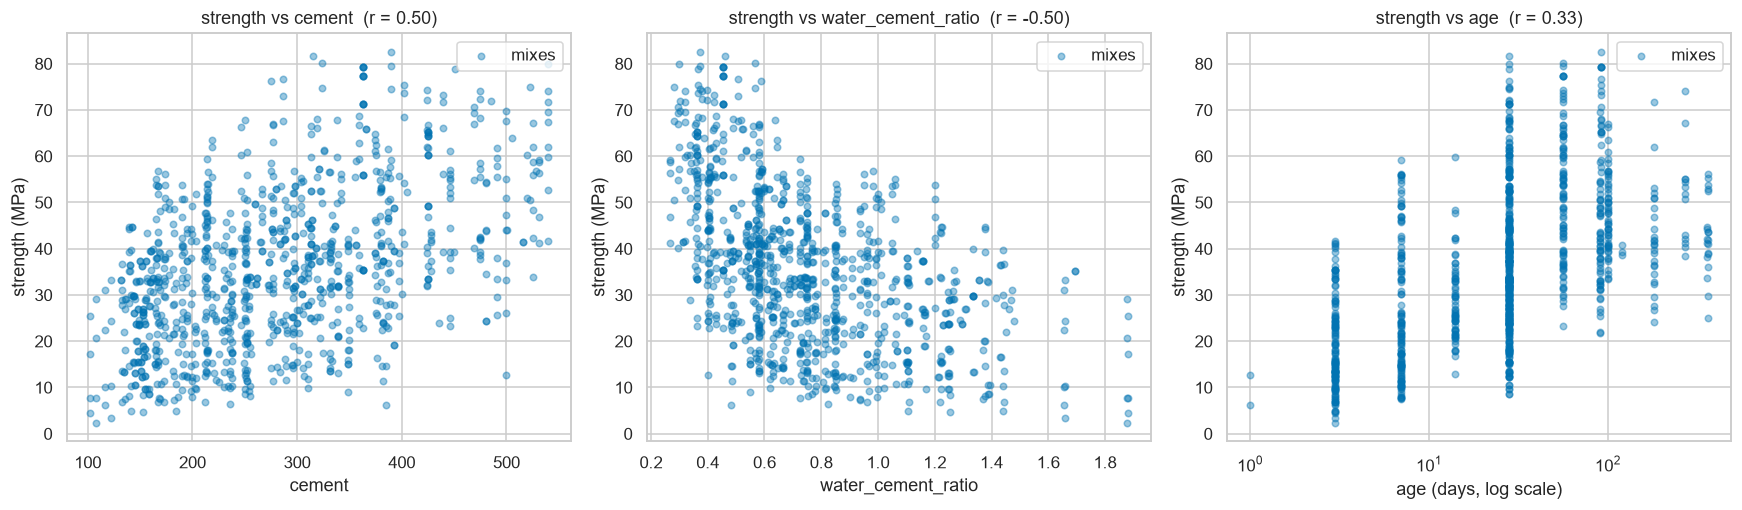

r( age          , strength ) = 0.329
r( log1p(age)   , strength ) = 0.549
r( sqrt(age)    , strength ) = 0.464


In [11]:
scatter_cols = ["cement", "water_cement_ratio", "age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df[TARGET], alpha=.4, s=18, label="mixes")
    ax.set_title(f"strength vs {col}  (r = {df[col].corr(df[TARGET]):.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("strength (MPa)")
    ax.legend(loc="upper right")
axes[2].set_xscale("log")
axes[2].set_xlabel("age (days, log scale)")
plt.show()

# Does compressing the age scale help? (motivates the log transform used in the pipeline)
print(f"r( age          , strength ) = {df['age'].corr(df[TARGET]):.3f}")
print(f"r( log1p(age)   , strength ) = {np.log1p(df['age']).corr(df[TARGET]):.3f}")
print(f"r( sqrt(age)    , strength ) = {np.sqrt(df['age']).corr(df[TARGET]):.3f}")

**Observation (feature vs target).** cement and water_cement_ratio both look fairly linear against strength (r = 0.50 and -0.50), and the direction makes sense, more cement is stronger concrete, more water relative to cement is weaker. age is the interesting one, the scatter is clearly curved, strength climbs fast early on and then flattens out. That's why raw age only gets r = 0.329 but log1p(age) jumps to 0.549, better than sqrt(age) too (0.464). log1p is the best of the three we tried, which is why the pipeline uses it.

---
# 3. Preprocessing and the train / test split


In [12]:
# De-duplication
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Before de-duplication: {df.shape[0]} rows")
print(f"After  de-duplication: {df_clean.shape[0]} rows   (removed {df.shape[0] - df_clean.shape[0]})")

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]
print(f"\nX shape: {X.shape}   y shape: {y.shape}")
print("Predictors:", list(X.columns))

Before de-duplication: 1030 rows
After  de-duplication: 1005 rows   (removed 25)

X shape: (1005, 13)   y shape: (1005,)
Predictors: ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'water_cement_ratio', 'total_binder', 'aggregate_to_cement', 'cement_water_interaction', 'age_strength_proxy']


### Cleaning decisions

- **Missing values:** none (section 2.1), so nothing to fill in. The shared pipeline still keeps a median `SimpleImputer` as a safety net in case a new row has a gap. Median over mean since several columns are skewed.
- **Duplicates:** the 25 fully duplicated rows get dropped above. Each row should be one lab specimen, and copies landing in both train and test would inflate the test score.
- **Categorical columns:** none, every column is numeric, so no encoding needed.

### Feature engineering

Five derived columns are already in the file. First we check each one is built only from the input columns and never from `strength` (target leakage):

In [13]:
# Rebuild every derived column from the raw inputs and compare with what is stored in the file.
rebuilt = {
    "water_cement_ratio":       df["water"] / df["cement"],
    "total_binder":             df["cement"] + df["slag"] + df["ash"],
    "aggregate_to_cement":      (df["coarseagg"] + df["fineagg"]) / df["cement"],
    "cement_water_interaction": df["cement"] * df["water"],
    "age_strength_proxy":       np.sqrt(df["age"]),
}
for name, values in rebuilt.items():
    print(f"{name:<26s} max |stored - rebuilt from inputs| = {np.abs(df[name] - values).max():.2e}")

water_cement_ratio         max |stored - rebuilt from inputs| = 1.85e-05
total_binder               max |stored - rebuilt from inputs| = 5.68e-14
aggregate_to_cement        max |stored - rebuilt from inputs| = 1.76e-04
cement_water_interaction   max |stored - rebuilt from inputs| = 7.28e-12
age_strength_proxy         max |stored - rebuilt from inputs| = 3.55e-15


The errors are tiny (at most about 2e-04, just rounding), so every derived column is built from the input columns only, none touch `strength`, so no target leakage. (`age_strength_proxy` is just `sqrt(age)` despite the name.)

Two more mix-design features get added below, computed row by row from the raw columns before the split, so nothing from the test rows leaks in.

In [14]:
# Two extra mix-design features, built from raw columns only (no use of the target).
X = X.assign(
    water_binder_ratio=X["water"] / X["total_binder"],
    scm_share=(X["slag"] + X["ash"]) / X["total_binder"],
)
new_features = ["water_binder_ratio", "scm_share"]

print("Correlation of the new features with strength:")
print(X[new_features].corrwith(y).round(3).to_string())
print(f"\nNumber of predictors is now {X.shape[1]}")

Correlation of the new features with strength:
water_binder_ratio   -0.611
scm_share            -0.111

Number of predictors is now 15


**Why these two features**

water_binder_ratio divides by the whole binder (cement + slag + ash) instead of just cement, since slag and ash react with water too, not only cement. It actually beats the original water_cement_ratio on correlation, -0.611 vs -0.501, so that one seems to have paid off. scm_share (the slag+ash share of the binder) is weaker on its own, r = -0.111, but we kept it because we think its real effect runs through age rather than by itself, slow-reacting binder should matter more for long-cured mixes than young ones, so a single correlation number probably undersells it. We're least confident defending scm_share of the two, but the tree importances later (section 10) suggest it's not dead weight.

                          n_outliers   pct
age                               59  5.87
age_strength_proxy                33  3.28
water_cement_ratio                18  1.79
water                             15  1.49
superplastic                      10  1.00
aggregate_to_cement                8  0.80
water_binder_ratio                 6  0.60
cement_water_interaction           6  0.60
fineagg                            5  0.50
slag                               2  0.20
cement                             0  0.00
coarseagg                          0  0.00
ash                                0  0.00
total_binder                       0  0.00
scm_share                          0  0.00

Rows with at least one flagged value: 111 of 1005


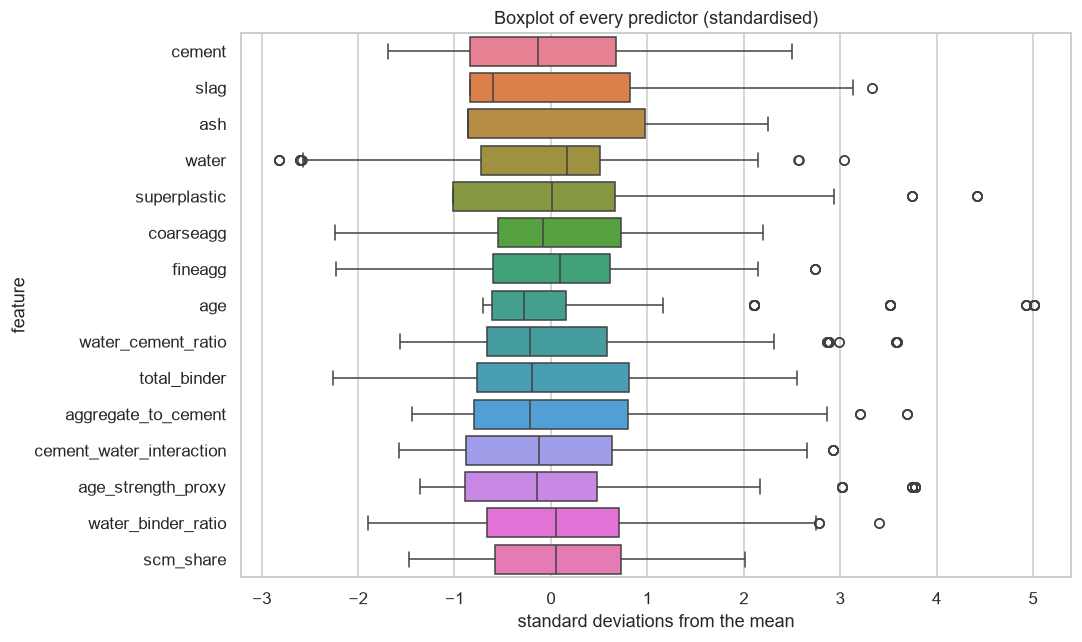

In [15]:
q1, q3 = X.quantile(0.25), X.quantile(0.75)
iqr = q3 - q1
is_outlier = (X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)

outlier_summary = pd.DataFrame({
    "n_outliers": is_outlier.sum(),
    "pct":        (is_outlier.mean() * 100).round(2),
}).sort_values("n_outliers", ascending=False)
print(outlier_summary.to_string())
print(f"\nRows with at least one flagged value: {is_outlier.any(axis=1).sum()} of {len(X)}")

# Boxplot of the standardised features, so they can be compared on one axis.
X_std = (X - X.mean()) / X.std()
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=X_std, orient="h", ax=ax)
ax.set_title("Boxplot of every predictor (standardised)")
ax.set_xlabel("standard deviations from the mean")
ax.set_ylabel("feature")
plt.show()

**Decision: keep the flagged rows.** 111 of 1005 rows got flagged, most of it from age (59 rows), and that's just because some mixes were cured a lot longer than most, not a data error. Dropping 11% of a dataset this size felt like more damage than it's worth, especially since age already gets compressed by log1p, and half the models we're using (the tree-based ones) don't care about outliers anyway.

## Train / test split

We stratify on binned `strength` (5 quantile bins) instead of a pure random split, so the small held-out set still covers the full strength range.

In [16]:
strength_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strength_bins,
)

print(f"Training set : {X_train.shape[0]} rows  ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} rows  ({TEST_SIZE*100:.0f}%)")

print("\nTarget distribution check (the split must not shift the target):")
print(pd.DataFrame({
    "train": y_train.describe(),
    "test":  y_test.describe(),
}).round(3).to_string())

Training set : 804 rows  (80%)
Test set     : 201 rows  (20%)

Target distribution check (the split must not shift the target):
         train     test
count  804.000  201.000
mean    35.264   35.194
std     16.323   16.171
min      2.330    3.320
25%     23.520   23.350
50%     33.745   34.670
75%     45.080   44.520
max     82.600   79.300


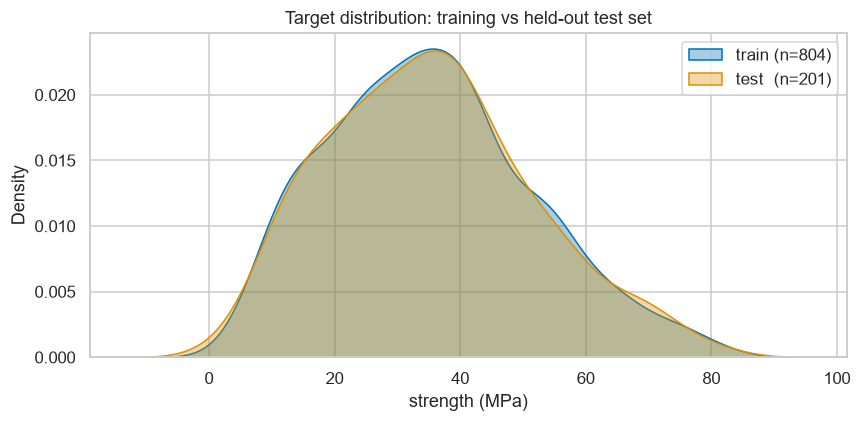

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(y_train, label=f"train (n={len(y_train)})", fill=True, alpha=.35, ax=ax)
sns.kdeplot(y_test,  label=f"test  (n={len(y_test)})",  fill=True, alpha=.35, ax=ax)
ax.set_title("Target distribution: training vs held-out test set")
ax.set_xlabel("strength (MPa)")
ax.legend()
plt.show()

## Shared preprocessing pipeline

Every model in this notebook shares this preprocessing. `age` gets median-imputed then log1p'd (it's heavily right-skewed, section 2.5); everything else just gets median-imputed. Both branches get scaled afterwards. Wrapping it in a `Pipeline` means `GridSearchCV` refits it from scratch on each CV fold, so no fold's statistics leak into another.

In [18]:
LOG_COLS   = ["age"]
OTHER_COLS = [c for c in X.columns if c not in LOG_COLS]

log_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p",  FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=True)),
])

column_transformer = ColumnTransformer(
    transformers=[
        ("log_age", log_pipe,                             LOG_COLS),
        ("passthru", SimpleImputer(strategy="median"),    OTHER_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# THE shared preprocessor. Cloned into every model pipeline.
preprocessor = Pipeline([
    ("columns", column_transformer),
    ("scale",   StandardScaler()),
])

preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_age', ...), ('passthru', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_

In [19]:
def make_pipe(model):
    """Wrap any estimator in the shared preprocessing recipe (fresh clone each time)."""
    return Pipeline([("prep", clone(preprocessor)), ("model", model)])


# Materialise the preprocessed matrices once, just for inspection below.
# Models themselves always re-fit the preprocessor inside their own pipeline/CV folds.
_prep_fitted   = clone(preprocessor).fit(X_train)
FEATURE_NAMES  = list(_prep_fitted.get_feature_names_out())
X_train_prep   = pd.DataFrame(_prep_fitted.transform(X_train), columns=FEATURE_NAMES)
X_test_prep    = pd.DataFrame(_prep_fitted.transform(X_test),  columns=FEATURE_NAMES)

print("Feature names after preprocessing (note: 'age' now holds log1p(age)):")
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:2d}. {f}")

print(f"\nX_train_prep: {X_train_prep.shape}   X_test_prep: {X_test_prep.shape}")
print("\nSanity check — training features are standardised (mean 0, std 1):")
print(pd.DataFrame({"mean": X_train_prep.mean(), "std": X_train_prep.std(ddof=0)}).round(4).to_string())

Feature names after preprocessing (note: 'age' now holds log1p(age)):
   1. age
   2. cement
   3. slag
   4. ash
   5. water
   6. superplastic
   7. coarseagg
   8. fineagg
   9. water_cement_ratio
  10. total_binder
  11. aggregate_to_cement
  12. cement_water_interaction
  13. age_strength_proxy
  14. water_binder_ratio
  15. scm_share

X_train_prep: (804, 15)   X_test_prep: (201, 15)

Sanity check — training features are standardised (mean 0, std 1):
                          mean  std
age                        0.0  1.0
cement                    -0.0  1.0
slag                      -0.0  1.0
ash                        0.0  1.0
water                     -0.0  1.0
superplastic              -0.0  1.0
coarseagg                 -0.0  1.0
fineagg                   -0.0  1.0
water_cement_ratio         0.0  1.0
total_binder               0.0  1.0
aggregate_to_cement        0.0  1.0
cement_water_interaction   0.0  1.0
age_strength_proxy         0.0  1.0
water_binder_ratio         0.0  1.0


---
# 4. Evaluation harness

One scoring function for every model: fit on `X_train`, score on the same held-out `X_test`, record R², RMSE, and MAE.

In [20]:
CV = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = {}   # model name -> metric dict
fitted  = {}   # model name -> fitted estimator


def evaluate(name, estimator, notes=""):
    """Fit on the training split, score on the held-out test set, record R2/RMSE/MAE."""
    estimator.fit(X_train, y_train)

    pred_tr = estimator.predict(X_train)
    pred_te = estimator.predict(X_test)

    row = {
        "Train R2":  r2_score(y_train, pred_tr),
        "Test R2":   r2_score(y_test,  pred_te),
        "Test RMSE": root_mean_squared_error(y_test, pred_te),
        "Test MAE":  mean_absolute_error(y_test, pred_te),
        "Notes":     notes,
    }
    row["Overfit gap"] = row["Train R2"] - row["Test R2"]

    results[name] = row
    fitted[name]  = estimator

    print(f"--- {name} ---")
    print(f"  Train R2    : {row['Train R2']:.4f}")
    print(f"  Test  R2    : {row['Test R2']:.4f}")
    print(f"  Test  RMSE  : {row['Test RMSE']:.4f} MPa")
    print(f"  Test  MAE   : {row['Test MAE']:.4f} MPa")
    print(f"  Overfit gap : {row['Overfit gap']:.4f}")
    if notes:
        print(f"  Config      : {notes}")
    return estimator

---
# 5. Model 1 - Linear Regression (baseline)

Ordinary Least Squares: fits one flat hyperplane across all 15 features that minimises squared error. No hyperparameters, it's as simple as regression gets, and it's the baseline every other model needs to beat.

In [21]:
lin = make_pipe(LinearRegression())
evaluate("1. Linear Regression", lin, notes="OLS, no hyperparameters")

--- 1. Linear Regression ---
  Train R2    : 0.8283
  Test  R2    : 0.8296
  Test  RMSE  : 6.6594 MPa
  Test  MAE   : 5.1824 MPa
  Overfit gap : -0.0012
  Config      : OLS, no hyperparameters


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

Since the pipeline standardises every feature (mean 0, std 1), the coefficients below are **standardised betas**: the change in strength (MPa) per **1 standard deviation** increase in that feature. That's what makes them comparable across features that would otherwise sit on very different scales.

Intercept: 35.2644 MPa (predicted strength for an average mix)

                 feature  coefficient
                     age      15.0972
     aggregate_to_cement     -13.3007
               scm_share      10.8482
                   water      -8.5378
cement_water_interaction       7.8892
      water_cement_ratio       6.7114
      age_strength_proxy      -5.2736
                 fineagg       3.0289
               coarseagg       2.4664
            total_binder       2.2387
                  cement       2.2142
      water_binder_ratio       1.5451
                     ash      -1.3926
                    slag       0.7557
            superplastic      -0.1195


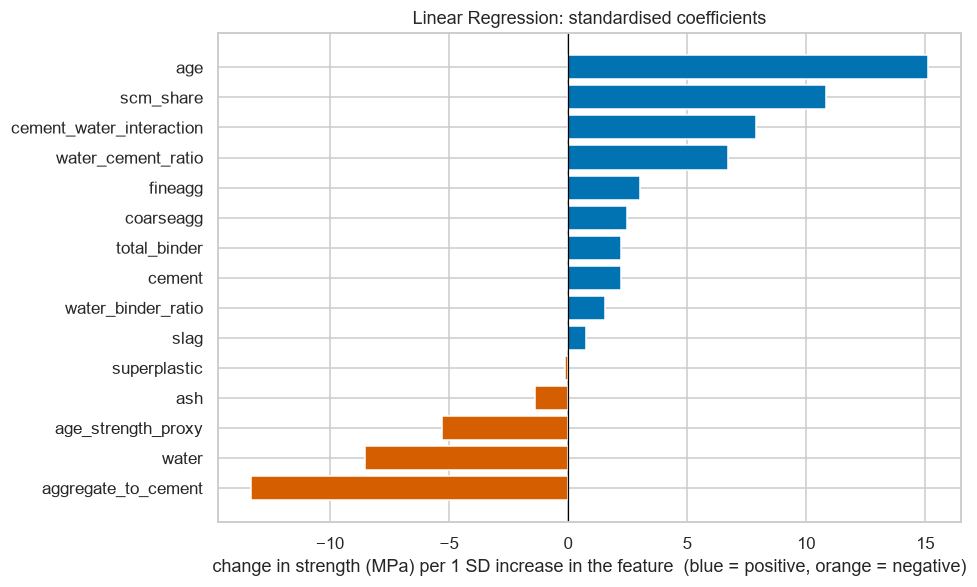

In [22]:
coef = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "coefficient": lin.named_steps["model"].coef_,
})
coef["abs"] = coef["coefficient"].abs()
coef = coef.sort_values("abs", ascending=False).reset_index(drop=True)

print(f"Intercept: {lin.named_steps['model'].intercept_:.4f} MPa (predicted strength for an average mix)\n")
print(coef[["feature", "coefficient"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
order  = coef.sort_values("coefficient")
colors = ["#D55E00" if v < 0 else "#0173B2" for v in order["coefficient"]]   # colourblind-safe pair
ax.barh(order["feature"], order["coefficient"], color=colors)
ax.axvline(0, color="black", lw=.8)
ax.set_title("Linear Regression: standardised coefficients")
ax.set_xlabel("change in strength (MPa) per 1 SD increase in the feature  (blue = positive, orange = negative)")
plt.show()

`age` (log-scaled) has by far the largest positive coefficient. A few others don't match their raw correlation with strength: `age_strength_proxy` is negative despite correlating positively, `water_cement_ratio` and `water_binder_ratio` are positive despite correlating negatively, and `scm_share` is large and positive off a weak negative correlation.

That's multicollinearity: when features carry overlapping information, the model can't tell which deserves the credit, so it splits weight between them however fits best, sign flips included. Makes sense here since the derived columns are built from the same raw ones (`total_binder = cement + slag + ash` exactly, `age_strength_proxy` is just a function of `age`). Predictions stay fine, but no single coefficient in a group like this can be trusted alone. Ridge and Lasso below are the standard fix.

---
# 6. Model 2 - Ridge Regression (L2)

Ridge adds an `alpha * ||w||²` penalty, `alpha` times the sum of every coefficient squared, which keeps coefficients small without forcing any to exactly zero. Good fit for the collinear features from section 5: instead of two near-duplicate columns fighting with huge opposite-sign coefficients, Ridge spreads the weight across both. `alpha` is tuned with 5-fold `GridSearchCV`.

In [23]:
alphas = np.logspace(-3, 4, 60)

ridge_gs = GridSearchCV(
    make_pipe(Ridge(random_state=RANDOM_STATE)),
    param_grid={"model__alpha": alphas},
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
ridge_gs.fit(X_train, y_train)

print(f"Best alpha : {ridge_gs.best_params_['model__alpha']:.4f}")
print(f"Best CV R2 : {ridge_gs.best_score_:.4f}")

evaluate("2. Ridge Regression", ridge_gs.best_estimator_,
         notes=f"alpha={ridge_gs.best_params_['model__alpha']:.4f}")

Best alpha : 0.4075
Best CV R2 : 0.8192
--- 2. Ridge Regression ---
  Train R2    : 0.8282
  Test  R2    : 0.8301
  Test  RMSE  : 6.6488 MPa
  Test  MAE   : 5.1733 MPa
  Overfit gap : -0.0019
  Config      : alpha=0.4075


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

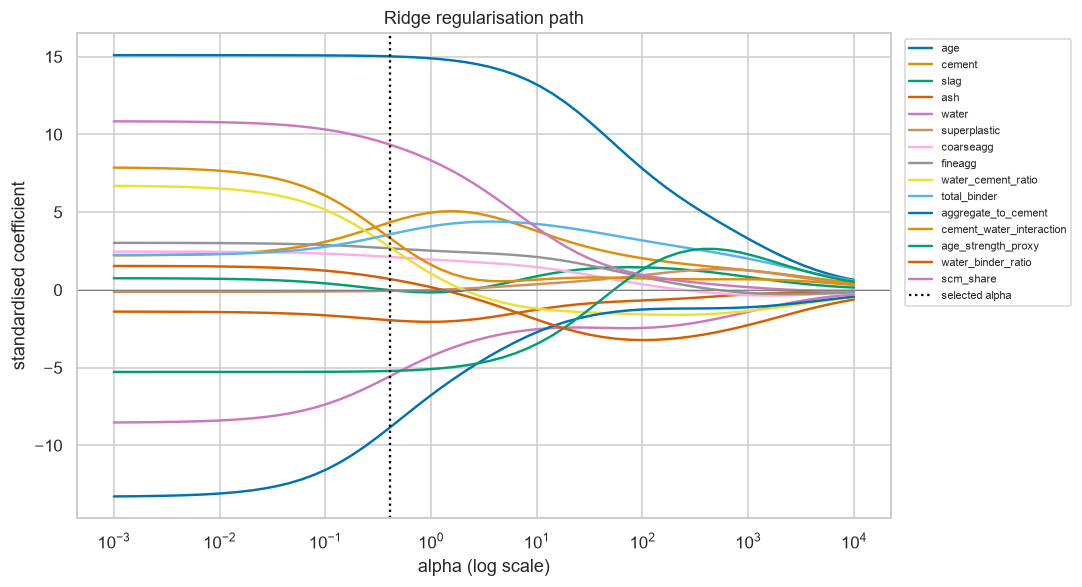

In [24]:
# How coefficients shrink as the L2 penalty grows.
paths = []
for a in alphas:
    p = make_pipe(Ridge(alpha=a, random_state=RANDOM_STATE)).fit(X_train, y_train)
    paths.append(p.named_steps["model"].coef_)
ridge_path = pd.DataFrame(paths, index=alphas, columns=FEATURE_NAMES)

fig, ax = plt.subplots(figsize=(10, 5.5))
for c in FEATURE_NAMES:
    ax.plot(ridge_path.index, ridge_path[c], label=c, lw=1.6)
ax.set_xscale("log")
ax.axvline(ridge_gs.best_params_["model__alpha"], ls=":", color="black", label="selected alpha")
ax.axhline(0, color="grey", lw=.7)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("standardised coefficient")
ax.set_title("Ridge regularisation path")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7.5)
plt.show()

Ridge keeps all 15 features and shrinks every coefficient toward zero, but none hit exactly zero. The tuned `alpha` is small (about 0.4), so shrinkage is mild: some big coefficients shrink a lot (`water_cement_ratio` from +6.7 to +2.8, `aggregate_to_cement` from -13.3 to -8.9), but the sign problems from Linear Regression stay (`age_strength_proxy` still negative, `water_cement_ratio` still positive). Test R² barely moves from OLS, which makes sense with about 800 rows and 15 features, not much variance for Ridge to remove.

In [25]:
# Small helper reused by every remaining model: plots the CV validation curve
# from a 1-D GridSearchCV sweep (train score vs validation score vs the tuned param).
def plot_tuning(cv_results, param, log_x=False, title="", xlabel=None):
    res = pd.DataFrame(cv_results)
    col = f"param_{param}"
    res = res.sort_values(col)
    x   = res[col].astype(float)

    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(x, res["mean_train_score"], "o--", label="train R2 (CV mean)", color="#a0aec0")
    ax.plot(x, res["mean_test_score"],  "o-",  label="validation R2 (CV mean)", color="#2b6cb0")
    ax.fill_between(x,
                     res["mean_test_score"] - res["std_test_score"],
                     res["mean_test_score"] + res["std_test_score"],
                     alpha=.18, color="#2b6cb0")
    best = res.loc[res["mean_test_score"].idxmax()]
    ax.axvline(float(best[col]), ls=":", color="#c53030", label=f"best = {float(best[col]):g}")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel or param.split("__")[-1])
    ax.set_ylabel("R2")
    ax.set_title(title or f"Validation curve — {param.split('__')[-1]}")
    ax.legend()
    plt.show()

---
# 7. Model 3 - Lasso Regression (L1)

Lasso uses `alpha * ||w||₁`, `alpha` times the sum of absolute coefficient values, instead of Ridge's squared penalty. That shape lets Lasso push coefficients **exactly to zero**, so it does feature selection automatically. `alpha` tuned the same way, with 5-fold `GridSearchCV`.

Best alpha : 0.01124
Best CV R2 : 0.8197


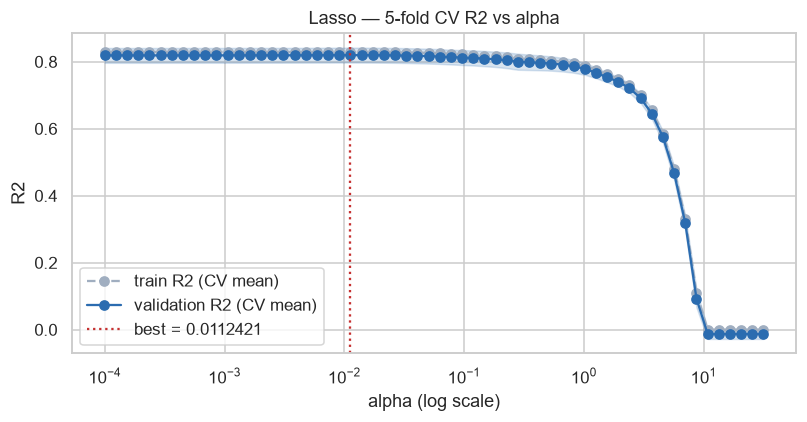

--- 3. Lasso Regression ---
  Train R2    : 0.8278
  Test  R2    : 0.8302
  Test  RMSE  : 6.6462 MPa
  Test  MAE   : 5.1700 MPa
  Overfit gap : -0.0024
  Config      : alpha=0.01124


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

In [26]:
lasso_alphas = np.logspace(-4, 1.5, 60)

lasso_gs = GridSearchCV(
    make_pipe(Lasso(max_iter=50_000, random_state=RANDOM_STATE)),
    param_grid={"model__alpha": lasso_alphas},
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
lasso_gs.fit(X_train, y_train)

print(f"Best alpha : {lasso_gs.best_params_['model__alpha']:.5f}")
print(f"Best CV R2 : {lasso_gs.best_score_:.4f}")

plot_tuning(lasso_gs.cv_results_, "model__alpha", log_x=True,
            title="Lasso — 5-fold CV R2 vs alpha", xlabel="alpha (log scale)")

evaluate("3. Lasso Regression", lasso_gs.best_estimator_,
         notes=f"alpha={lasso_gs.best_params_['model__alpha']:.5f}")

In [27]:
# Which features did Lasso zero out completely?
lasso_coef = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "coefficient": lasso_gs.best_estimator_.named_steps["model"].coef_,
})
n_zero = int((lasso_coef["coefficient"] == 0).sum())
print(f"Features eliminated by Lasso: {n_zero} / {len(FEATURE_NAMES)}")
print(lasso_coef.sort_values("coefficient", key=abs, ascending=False).round(4).to_string(index=False))

Features eliminated by Lasso: 5 / 15
                 feature  coefficient
                     age      14.9082
               scm_share       8.0154
                  cement       6.4734
     aggregate_to_cement      -5.6395
      age_strength_proxy      -5.1045
            total_binder       3.9026
                   water      -3.4453
                 fineagg       2.3188
                     ash      -1.8973
               coarseagg       1.7934
                    slag       0.0000
            superplastic      -0.0000
      water_cement_ratio      -0.0000
cement_water_interaction       0.0000
      water_binder_ratio      -0.0000


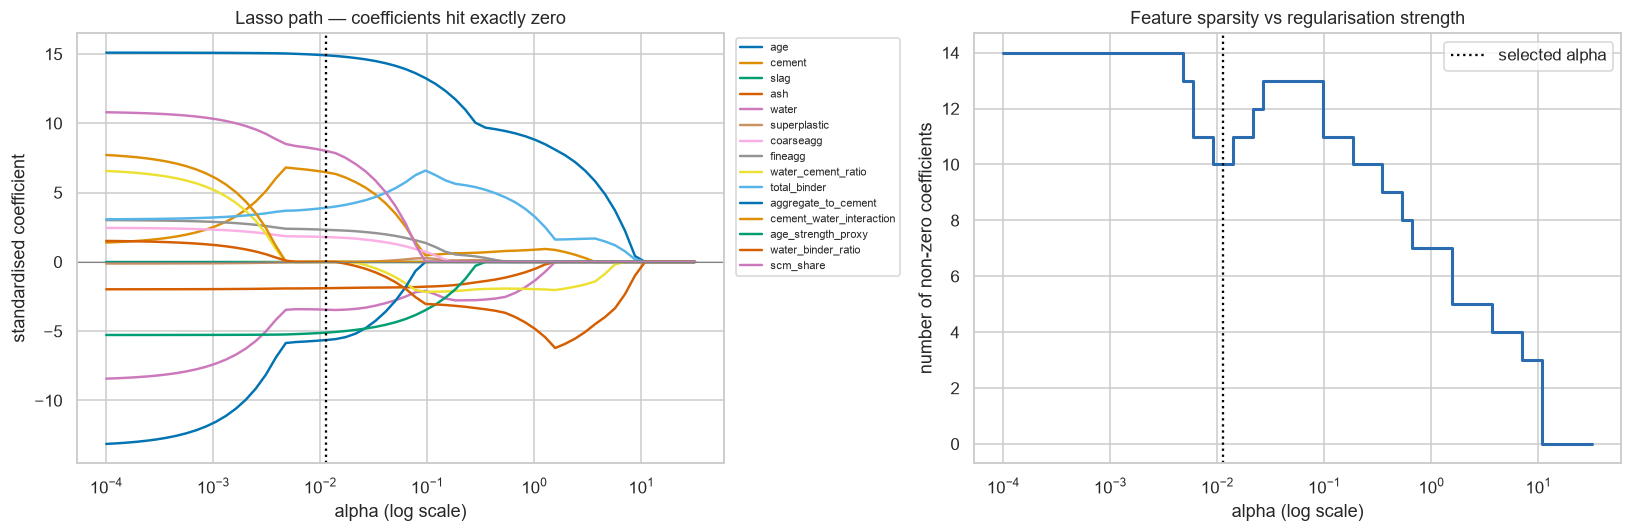

In [28]:
# Sparsity as a function of alpha: how many coefficients survive?
n_nonzero, path_coefs = [], []
for a in lasso_alphas:
    m = make_pipe(Lasso(alpha=a, max_iter=50_000, random_state=RANDOM_STATE)).fit(X_train, y_train)
    c = m.named_steps["model"].coef_
    n_nonzero.append(int((c != 0).sum()))
    path_coefs.append(c)
lasso_path = pd.DataFrame(path_coefs, index=lasso_alphas, columns=FEATURE_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for c in FEATURE_NAMES:
    axes[0].plot(lasso_path.index, lasso_path[c], label=c, lw=1.6)
axes[0].set_xscale("log")
axes[0].axvline(lasso_gs.best_params_["model__alpha"], ls=":", color="black")
axes[0].axhline(0, color="grey", lw=.7)
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("standardised coefficient")
axes[0].set_title("Lasso path — coefficients hit exactly zero")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

axes[1].step(lasso_alphas, n_nonzero, where="post", color="#2b6cb0", lw=2)
axes[1].set_xscale("log")
axes[1].axvline(lasso_gs.best_params_["model__alpha"], ls=":", color="black", label="selected alpha")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("number of non-zero coefficients")
axes[1].set_title("Feature sparsity vs regularisation strength")
axes[1].legend()

plt.subplots_adjust(wspace=.5)
plt.show()

Ridge's coefficients only shrink. Lasso's reach exactly zero. At the CV-optimal `alpha` (about 0.011), Lasso zeroes out 5 of the 15: `slag`, `superplastic`, `water_cement_ratio`, `cement_water_interaction`, `water_binder_ratio`. Both water-to-binder ratios get dropped while `water` and `cement` survive, so L1 prefers the raw columns here. `age` and `age_strength_proxy` are both kept but still have opposite signs, so the collinear age pair isn't resolved either. The exact set eliminated depends on the data and grid, so re-check the list above if either changes.

---
# 8. Model 4 - ElasticNet Regression (L1 + L2)

Blends both penalties: `alpha * (l1_ratio * ||w||₁ + 0.5*(1-l1_ratio) * ||w||²)`. `l1_ratio=1` is pure Lasso, `l1_ratio=0` is pure Ridge. The blend matters because Lasso alone tends to arbitrarily pick one feature out of a correlated group and zero the rest; mixing in some Ridge lets correlated features move together instead. Both `alpha` and `l1_ratio` tuned jointly.

In [29]:
enet_grid = {
    "model__alpha":    np.logspace(-4, 1, 30),
    "model__l1_ratio": [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0],
}

enet_gs = GridSearchCV(
    make_pipe(ElasticNet(max_iter=50_000, random_state=RANDOM_STATE)),
    param_grid=enet_grid, scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
enet_gs.fit(X_train, y_train)

print(f"Best alpha    : {enet_gs.best_params_['model__alpha']:.5f}")
print(f"Best l1_ratio : {enet_gs.best_params_['model__l1_ratio']}")
print(f"Best CV R2    : {enet_gs.best_score_:.4f}")

evaluate("4. ElasticNet Regression", enet_gs.best_estimator_,
         notes=(f"alpha={enet_gs.best_params_['model__alpha']:.5f}, "
                f"l1_ratio={enet_gs.best_params_['model__l1_ratio']}"))

Best alpha    : 0.01172
Best l1_ratio : 1.0
Best CV R2    : 0.8196
--- 4. ElasticNet Regression ---
  Train R2    : 0.8278
  Test  R2    : 0.8302
  Test  RMSE  : 6.6464 MPa
  Test  MAE   : 5.1699 MPa
  Overfit gap : -0.0024
  Config      : alpha=0.01172, l1_ratio=1.0


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

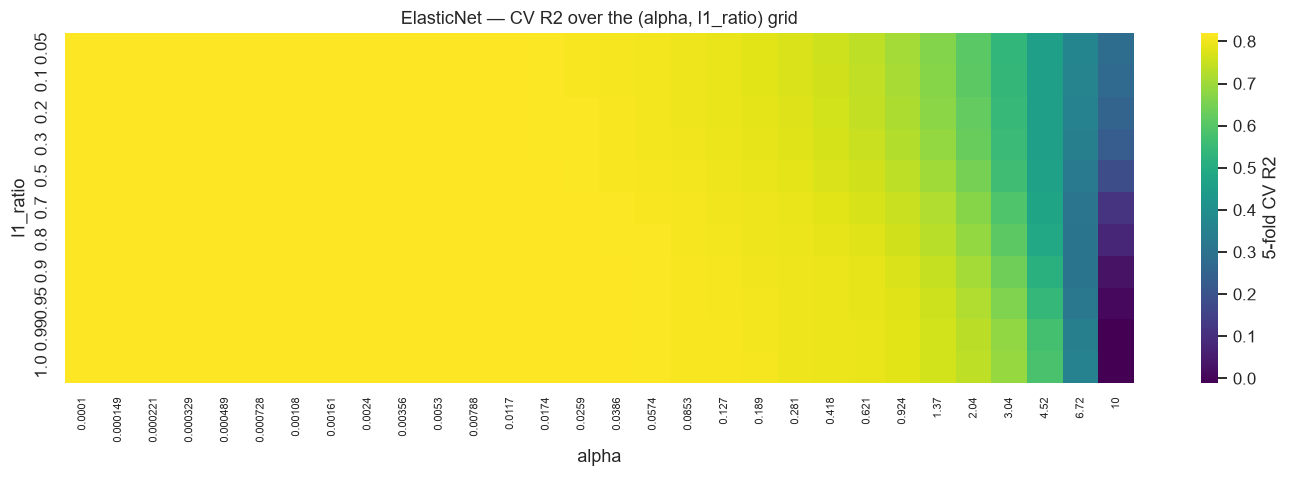

Non-zero coefficients: 10 / 15


In [30]:
# CV R2 across the whole (alpha, l1_ratio) grid.
piv = (pd.DataFrame(enet_gs.cv_results_)
         .pivot_table(index="param_model__l1_ratio", columns="param_model__alpha",
                      values="mean_test_score"))

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(piv, cmap="viridis", ax=ax,
            cbar_kws={"label": "5-fold CV R2"},
            xticklabels=[f"{float(c):.3g}" for c in piv.columns])
ax.set_title("ElasticNet — CV R2 over the (alpha, l1_ratio) grid")
ax.set_xlabel("alpha")
ax.set_ylabel("l1_ratio")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.show()

enet_coef = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "coefficient": enet_gs.best_estimator_.named_steps["model"].coef_,
})
print(f"Non-zero coefficients: {(enet_coef['coefficient'] != 0).sum()} / {len(FEATURE_NAMES)}")

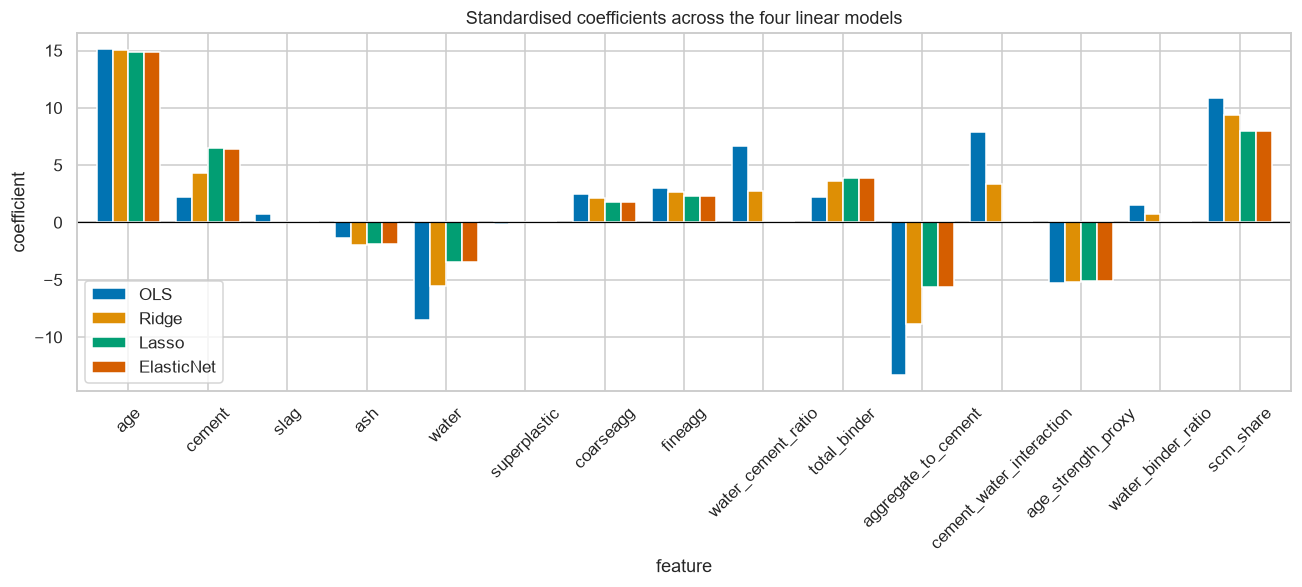

In [31]:
# Side-by-side comparison of all four linear models' coefficients.
comp = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "OLS":        lin.named_steps["model"].coef_,
    "Ridge":      ridge_gs.best_estimator_.named_steps["model"].coef_,
    "Lasso":      lasso_gs.best_estimator_.named_steps["model"].coef_,
    "ElasticNet": enet_gs.best_estimator_.named_steps["model"].coef_,
}).set_index("feature")

fig, ax = plt.subplots(figsize=(12, 5.5))
comp.plot(kind="bar", ax=ax, width=.8)
ax.axhline(0, color="black", lw=.8)
ax.set_title("Standardised coefficients across the four linear models")
ax.set_ylabel("coefficient")
ax.tick_params(axis="x", rotation=45)
plt.show()

All four linear models land at roughly the same test R². The limiting factor isn't variance, which regularisation reduces, it's **bias**: a straight line structurally can't capture how concrete strength depends on its ingredients. The next model drops that assumption.

---
# 9. Model 5 - Polynomial Regression

`PolynomialFeatures(degree=d)` builds new columns from the 15 inputs, squares, products like `cement × age`, up to degree `d`, then `LinearRegression` fits on the expansion. Cheapest way to let a linear model capture curves and interactions. The cost is size: degree 2 gives 135 features, degree 3 gives 815, more than the 804 training rows, so overfitting risk grows fast. `degree` is tuned with `GridSearchCV`.

In [32]:
poly_degrees = [1, 2, 3]

poly_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression()),
])

poly_gs = GridSearchCV(
    poly_pipe, param_grid={"poly__degree": poly_degrees},
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
poly_gs.fit(X_train, y_train)

print(f"Best degree : {poly_gs.best_params_['poly__degree']}")
print(f"Best CV R2  : {poly_gs.best_score_:.4f}")

Best degree : 2
Best CV R2  : 0.8390


 degree  n_features  Train R2    CV R2  Test R2  Test RMSE
      1          15    0.8283   0.8189   0.8296     6.6594
      2         135    0.9268   0.8390   0.8712     5.7899
      3         815    0.9889 -17.7527  -5.9048    42.3862


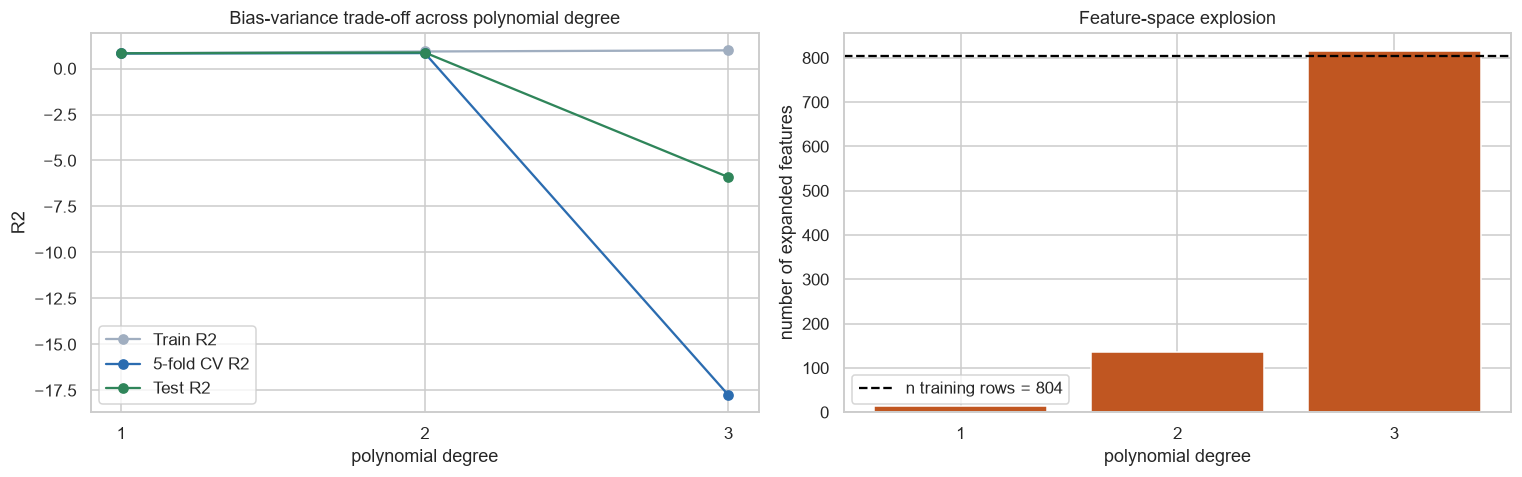

In [33]:
# Explicit degree-by-degree comparison: train vs CV vs test.
rows = []
for d in poly_degrees:
    p = Pipeline([
        ("prep", clone(preprocessor)),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression()),
    ]).fit(X_train, y_train)

    n_feat = p.named_steps["poly"].n_output_features_
    cv_r2  = cross_val_score(clone(p), X_train, y_train, cv=CV, scoring="r2", n_jobs=4)
    rows.append({
        "degree":     d,
        "n_features": n_feat,
        "Train R2":   r2_score(y_train, p.predict(X_train)),
        "CV R2":      cv_r2.mean(),
        "Test R2":    r2_score(y_test, p.predict(X_test)),
        "Test RMSE":  root_mean_squared_error(y_test, p.predict(X_test)),
    })

poly_cmp = pd.DataFrame(rows)
print(poly_cmp.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(poly_cmp["degree"], poly_cmp["Train R2"], "o-", label="Train R2", color="#a0aec0")
axes[0].plot(poly_cmp["degree"], poly_cmp["CV R2"],    "o-", label="5-fold CV R2", color="#2b6cb0")
axes[0].plot(poly_cmp["degree"], poly_cmp["Test R2"],  "o-", label="Test R2", color="#2f855a")
axes[0].set_xticks(poly_degrees)
axes[0].set_xlabel("polynomial degree")
axes[0].set_ylabel("R2")
axes[0].set_title("Bias-variance trade-off across polynomial degree")
axes[0].legend()

axes[1].bar(poly_cmp["degree"].astype(str), poly_cmp["n_features"], color="#c05621")
axes[1].axhline(len(X_train), ls="--", color="black", label=f"n training rows = {len(X_train)}")
axes[1].set_xlabel("polynomial degree")
axes[1].set_ylabel("number of expanded features")
axes[1].set_title("Feature-space explosion")
axes[1].legend()

plt.show()

In [34]:
evaluate("5. Polynomial Regression", poly_gs.best_estimator_,
         notes=f"degree={poly_gs.best_params_['poly__degree']}, LinearRegression on expansion")

--- 5. Polynomial Regression ---
  Train R2    : 0.9268
  Test  R2    : 0.8712
  Test  RMSE  : 5.7899 MPa
  Test  MAE   : 4.2101 MPa
  Overfit gap : 0.0556
  Config      : degree=2, LinearRegression on expansion


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is ti

Degree 1 matches plain OLS (test R² 0.830, a sanity check). Degree 2 is a clear jump (0.871), so part of the signal is interactions and curvature. Degree 3 falls apart: train R² 0.989 but CV R² -17.8 and test R² -5.9 (RMSE 42 MPa), worse than just predicting the mean every time. With 815 features and 804 rows the model nearly memorises the training set and blows up on new mixes. `GridSearchCV` picks degree 2.

---
# 10. Model 6 - Decision Tree Regressor

Our first non-parametric model: no fixed formula, it asks a series of yes/no questions, like "is `water_binder_ratio` below 0.42?", splitting the data into smaller groups, then predicts the average strength of whichever group a new mix lands in. That naturally captures curves and interactions without engineering them by hand. Left alone it splits until every group has one or two points, essentially memorising the training set, so `max_depth`, `min_samples_leaf`, and `min_samples_split` get tuned together to stop that.

In [35]:
tree_grid = {
    "model__max_depth":         [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
    "model__min_samples_leaf":  [1, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10],
}

tree_gs = GridSearchCV(
    make_pipe(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    param_grid=tree_grid, scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
tree_gs.fit(X_train, y_train)

print("Best parameters:")
for k, v in tree_gs.best_params_.items():
    print(f"  {k.split('__')[-1]:<20s}= {v}")
print(f"Best CV R2 : {tree_gs.best_score_:.4f}")

evaluate("6. Decision Tree", tree_gs.best_estimator_,
         notes=", ".join(f"{k.split('__')[-1]}={v}" for k, v in tree_gs.best_params_.items()))

Best parameters:
  max_depth           = 10
  min_samples_leaf    = 10
  min_samples_split   = 2
Best CV R2 : 0.8182
--- 6. Decision Tree ---
  Train R2    : 0.9141
  Test  R2    : 0.8424
  Test  RMSE  : 6.4034 MPa
  Test  MAE   : 4.8640 MPa
  Overfit gap : 0.0717
  Config      : max_depth=10, min_samples_leaf=10, min_samples_split=2


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

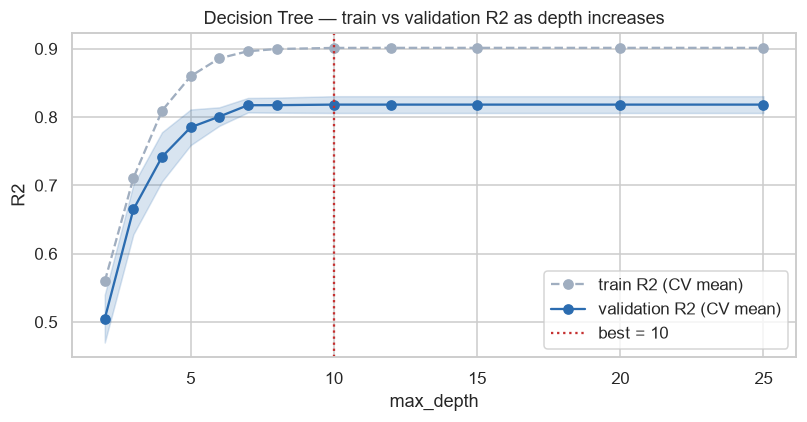

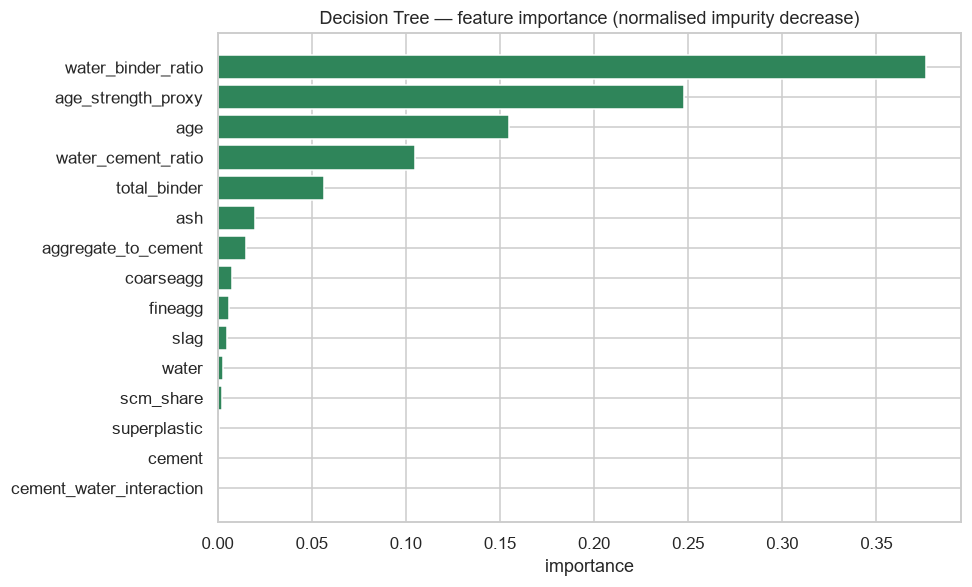

                 feature  importance
      water_binder_ratio      0.3764
      age_strength_proxy      0.2478
                     age      0.1547
      water_cement_ratio      0.1052
            total_binder      0.0564
                     ash      0.0200
     aggregate_to_cement      0.0149
               coarseagg      0.0074
                 fineagg      0.0058
                    slag      0.0048
                   water      0.0031
               scm_share      0.0021
            superplastic      0.0007
                  cement      0.0005
cement_water_interaction      0.0000


In [36]:
# Isolated max_depth sweep at the other best params — clearest picture of where a single tree overfits.
depth_gs = GridSearchCV(
    make_pipe(DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        min_samples_leaf=tree_gs.best_params_["model__min_samples_leaf"],
        min_samples_split=tree_gs.best_params_["model__min_samples_split"],
    )),
    param_grid={"model__max_depth": [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25]},
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
depth_gs.fit(X_train, y_train)

plot_tuning(depth_gs.cv_results_, "model__max_depth",
            title="Decision Tree — train vs validation R2 as depth increases", xlabel="max_depth")

tree_imp = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": tree_gs.best_estimator_.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
o = tree_imp.sort_values("importance")
ax.barh(o["feature"], o["importance"], color="#2f855a")
ax.set_title("Decision Tree — feature importance (normalised impurity decrease)")
ax.set_xlabel("importance")
plt.show()
print(tree_imp.round(4).to_string(index=False))

Validation R² climbs quickly with depth and flattens at about 0.818 from depth 10 on, while training R² flattens around 0.90. It doesn't decline because the tuned `min_samples_leaf=10` stops splits once a group gets small, which is what keeps this tree from overfitting.

Importance concentrates in `water_binder_ratio` (0.38), the two age columns combined (`age_strength_proxy` 0.25 plus `age` 0.15), and `water_cement_ratio` (0.11). `cement` scores almost zero, but only because its information is already covered by `total_binder` and the ratio columns, not because it's unimportant. Read this as "this group of features matters," not an exact ranking.

---
# 11. Model 7 - Random Forest Regressor

Trains a lot of decision trees and averages their predictions. Each tree sees a random sample of rows (with replacement, called bootstrapping) and only a random subset of features per split. That randomness makes the trees different from each other, and averaging cancels out their individual mistakes. Fixes the single tree's overfitting problem from section 10 directly. `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features` tuned together.

In [37]:
rf_grid = {
    "model__n_estimators":     [50, 100, 200, 300, 500],
    "model__max_depth":        [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features":     [1.0, "sqrt", 0.5],
}

rf_gs = GridSearchCV(
    make_pipe(RandomForestRegressor(random_state=RANDOM_STATE)),
    param_grid=rf_grid, scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
rf_gs.fit(X_train, y_train)

print("Best parameters:")
for k, v in rf_gs.best_params_.items():
    print(f"  {k.split('__')[-1]:<20s}= {v}")
print(f"Best CV R2 : {rf_gs.best_score_:.4f}")

evaluate("7. Random Forest", rf_gs.best_estimator_,
         notes=", ".join(f"{k.split('__')[-1]}={v}" for k, v in rf_gs.best_params_.items()))

Best parameters:
  max_depth           = 20
  max_features        = sqrt
  min_samples_leaf    = 1
  n_estimators        = 200
Best CV R2 : 0.8984


--- 7. Random Forest ---
  Train R2    : 0.9851
  Test  R2    : 0.9117
  Test  RMSE  : 4.7939 MPa
  Test  MAE   : 3.5343 MPa
  Overfit gap : 0.0734
  Config      : max_depth=20, max_features=sqrt, min_samples_leaf=1, n_estimators=200


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

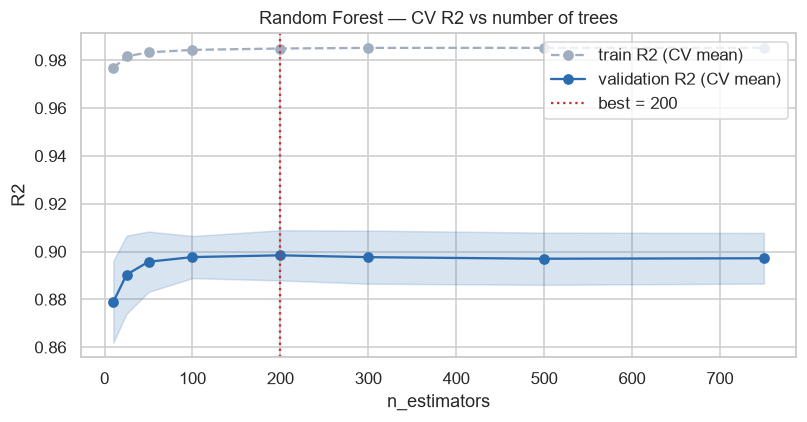

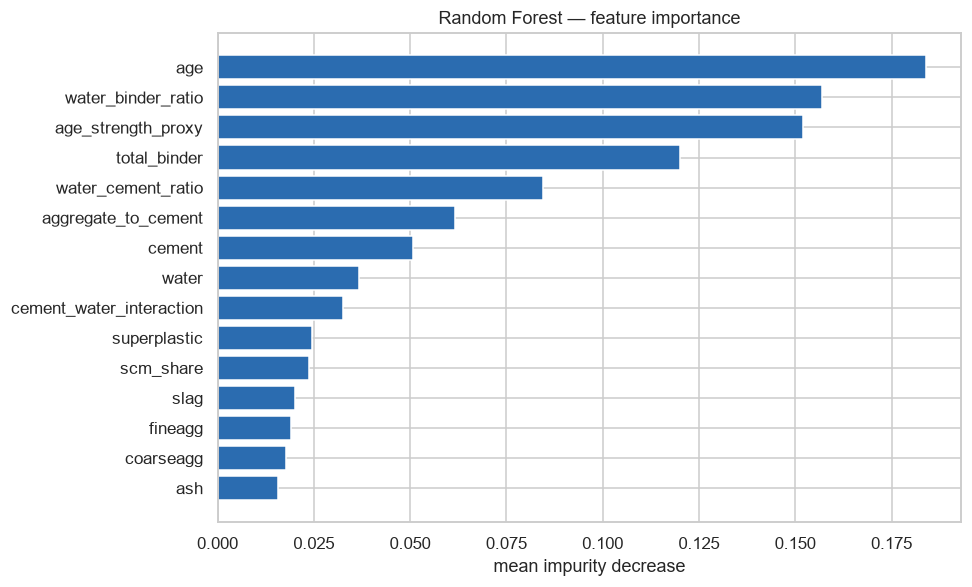

In [38]:
# Isolated n_estimators sweep at the best remaining settings.
best_rf = {k.split("__")[-1]: v for k, v in rf_gs.best_params_.items() if "n_estimators" not in k}

ne_gs = GridSearchCV(
    make_pipe(RandomForestRegressor(random_state=RANDOM_STATE, **best_rf)),
    param_grid={"model__n_estimators": [10, 25, 50, 100, 200, 300, 500, 750]},
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
ne_gs.fit(X_train, y_train)

plot_tuning(ne_gs.cv_results_, "model__n_estimators",
            title="Random Forest — CV R2 vs number of trees", xlabel="n_estimators")

rf_imp = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": rf_gs.best_estimator_.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
o = rf_imp.sort_values("importance")
ax.barh(o["feature"], o["importance"], color="#2b6cb0")
ax.set_title("Random Forest — feature importance")
ax.set_xlabel("mean impurity decrease")
plt.show()

CV R² climbs from 0.879 with 10 trees to about 0.898 at 100-200 trees, then flattens, so more trees past that just cost compute (a random forest doesn't overfit by adding trees). The search picked `max_features='sqrt'` over using all features: fewer choices per split makes the trees less alike, which helps since several columns are near-duplicates. Importances are also more evenly spread than the single tree's (biggest here is `age` at 0.18, versus 0.38 for the tree's top feature).

---
# 12. Model 8 - Gradient Boosting Regressor

Also builds a lot of trees, but one at a time: the first makes a rough prediction, the second is trained to fix what the first got wrong (its residuals), the third fixes what's still left, and so on, each correction added in a small step. Where Random Forest averages away noise, boosting chases down whatever error is left, usually the stronger approach on tabular data. `learning_rate` and `n_estimators` trade off directly (a smaller rate needs more trees), so they're tuned together with `max_depth` and `subsample`.

In [39]:
gb_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators":  [200, 400, 800],
    "model__max_depth":     [2, 3, 4, 5],
    "model__subsample":     [0.8, 1.0],
}

gb_gs = GridSearchCV(
    make_pipe(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_grid=gb_grid, scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
gb_gs.fit(X_train, y_train)

print("Best parameters:")
for k, v in gb_gs.best_params_.items():
    print(f"  {k.split('__')[-1]:<16s}= {v}")
print(f"Best CV R2 : {gb_gs.best_score_:.4f}")

evaluate("8. Gradient Boosting", gb_gs.best_estimator_,
         notes=", ".join(f"{k.split('__')[-1]}={v}" for k, v in gb_gs.best_params_.items()))

Best parameters:
  learning_rate   = 0.2
  max_depth       = 2
  n_estimators    = 800
  subsample       = 1.0
Best CV R2 : 0.9190


--- 8. Gradient Boosting ---
  Train R2    : 0.9847
  Test  R2    : 0.9257
  Test  RMSE  : 4.3959 MPa
  Test  MAE   : 3.0037 MPa
  Overfit gap : 0.0590
  Config      : learning_rate=0.2, max_depth=2, n_estimators=800, subsample=1.0


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

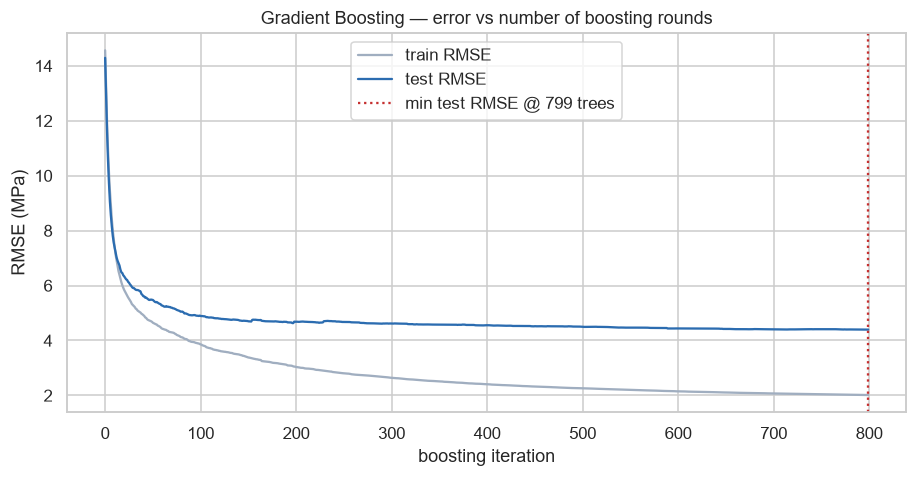

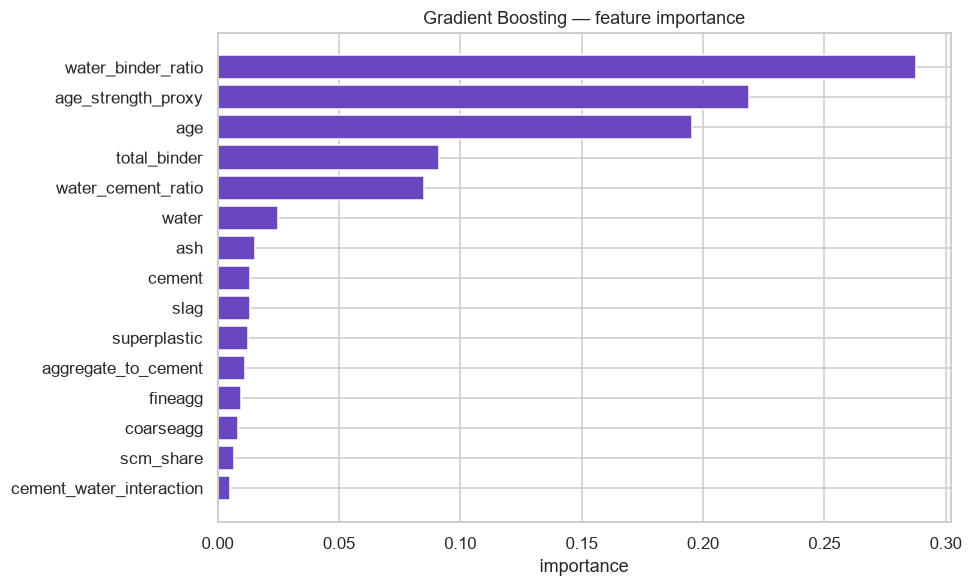

In [40]:
# Staged predictions: test error as boosting rounds accumulate.
gb_best   = gb_gs.best_estimator_
gb_model  = gb_best.named_steps["model"]
X_te_prep = gb_best.named_steps["prep"].transform(X_test)
X_tr_prep = gb_best.named_steps["prep"].transform(X_train)

test_curve  = [root_mean_squared_error(y_test,  p) for p in gb_model.staged_predict(X_te_prep)]
train_curve = [root_mean_squared_error(y_train, p) for p in gb_model.staged_predict(X_tr_prep)]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(train_curve, label="train RMSE", color="#a0aec0")
ax.plot(test_curve,  label="test RMSE",  color="#2b6cb0")
ax.axvline(int(np.argmin(test_curve)), ls=":", color="#c53030",
           label=f"min test RMSE @ {int(np.argmin(test_curve))} trees")
ax.set_xlabel("boosting iteration")
ax.set_ylabel("RMSE (MPa)")
ax.set_title("Gradient Boosting — error vs number of boosting rounds")
ax.legend()
plt.show()

gb_imp = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": gb_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
o = gb_imp.sort_values("importance")
ax.barh(o["feature"], o["importance"], color="#6b46c1")
ax.set_title("Gradient Boosting — feature importance")
ax.set_xlabel("importance")
plt.show()

`learning_rate` and `n_estimators` trade off: effective capacity is roughly their product times tree complexity, so they're tuned together. The search landed on a large rate (0.2), very shallow trees (`max_depth=2`), and 800 rounds. Test RMSE keeps dropping as rounds are added (4.68 MPa at 200, 4.56 at 400, 4.40 at 800) with no sign of turning back up. But the lowest value is at the last round, and both hyperparameters sit at the top of their grids, so a wider search might do slightly better.

---
# 13. Model 9 - Support Vector Regressor (SVR)

SVR draws a "tube" of width `epsilon` around the predicted curve. Points inside count as zero error; only points outside get penalised, proportional to how far out they are. With an RBF kernel the model effectively draws a curved tube instead of a straight one, using a similarity score based on distance rather than computing the curve explicitly. **Feature scaling is mandatory here** since that similarity score is a distance calculation, and the pipeline's `StandardScaler` handles it (section 19 shows what happens without it). Kernel, `C`, `gamma`, and `epsilon` are tuned together.

In [41]:
svr_grid = [
    {   # RBF and sigmoid take a gamma
        "model__kernel": ["rbf"],
        "model__C":      [1, 10, 50, 100, 300, 1000],
        "model__gamma":  ["scale", 0.01, 0.05, 0.1, 0.3],
        "model__epsilon":[0.1, 0.5, 1.0],
    },
    {   # linear kernel has no gamma
        "model__kernel": ["linear"],
        "model__C":      [0.1, 1, 10, 100],
        "model__epsilon":[0.1, 0.5, 1.0],
    },
    {   # polynomial kernel
        "model__kernel": ["poly"],
        "model__degree": [2, 3],
        "model__C":      [1, 10, 100],
        "model__gamma":  ["scale", 0.1],
        "model__epsilon":[0.1, 0.5],
    },
]

svr_gs = GridSearchCV(
    make_pipe(SVR()), param_grid=svr_grid,
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
svr_gs.fit(X_train, y_train)

print("Best parameters:")
for k, v in svr_gs.best_params_.items():
    print(f"  {k.split('__')[-1]:<10s}= {v}")
print(f"Best CV R2 : {svr_gs.best_score_:.4f}")

evaluate("9. Support Vector Regressor", svr_gs.best_estimator_,
         notes=", ".join(f"{k.split('__')[-1]}={v}" for k, v in svr_gs.best_params_.items()))

Best parameters:
  C         = 50
  epsilon   = 0.5
  gamma     = 0.05
  kernel    = rbf
Best CV R2 : 0.8979
--- 9. Support Vector Regressor ---
  Train R2    : 0.9378
  Test  R2    : 0.8939
  Test  RMSE  : 5.2533 MPa
  Test  MAE   : 3.5148 MPa
  Overfit gap : 0.0439
  Config      : C=50, epsilon=0.5, gamma=0.05, kernel=rbf


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

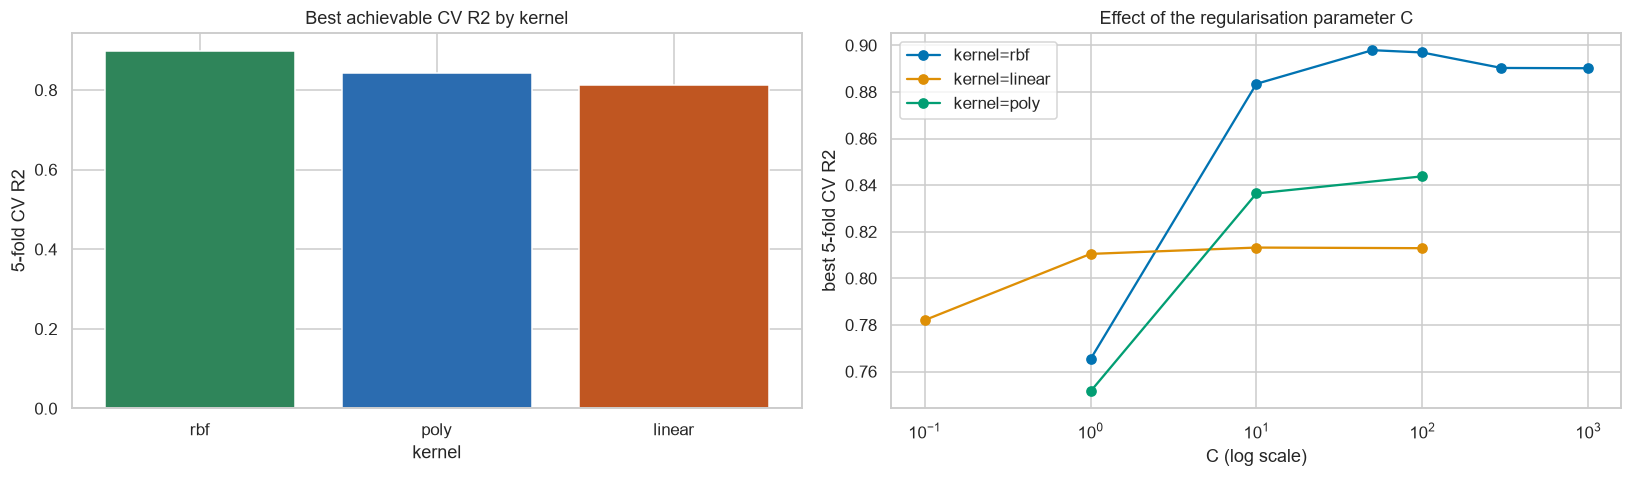

Support vectors used: 685 of 804 training points


In [42]:
res_svr = pd.DataFrame(svr_gs.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Which kernel wins?
kern = (res_svr.groupby("param_model__kernel")["mean_test_score"]
                .max().sort_values(ascending=False))
axes[0].bar(kern.index.astype(str), kern.values, color=["#2f855a", "#2b6cb0", "#c05621"])
axes[0].set_title("Best achievable CV R2 by kernel")
axes[0].set_ylabel("5-fold CV R2")
axes[0].set_xlabel("kernel")

# Effect of C for each kernel (best over the other params).
for k in res_svr["param_model__kernel"].unique():
    sub = (res_svr[res_svr["param_model__kernel"] == k]
             .groupby("param_model__C")["mean_test_score"].max())
    axes[1].plot(sub.index.astype(float), sub.values, "o-", label=f"kernel={k}")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("best 5-fold CV R2")
axes[1].set_title("Effect of the regularisation parameter C")
axes[1].legend()

plt.subplots_adjust(wspace=.3)
plt.show()

print(f"Support vectors used: {svr_gs.best_estimator_.named_steps['model'].n_support_.sum()} "
      f"of {len(X_train)} training points")

RBF wins clearly: best CV R² 0.898, against 0.844 for polynomial and 0.813 for linear. The linear-kernel score lands close to Ridge/Lasso/ElasticNet's (about 0.82), since a linear-kernel SVR is structurally a linear model. `C` sets the bias/variance trade-off (too small underfits), `gamma` sets how far each point's influence reaches (too small underfits, too large overfits to individual points), so both are tuned together.

---
# 14. Model 10 - K-Nearest Neighbors Regressor

The simplest model here: predict a new mix's strength as the average of its `k` closest training mixes, optionally weighted by distance. No training phase, no formula, the "model" is just the stored data. That makes it **the most scaling-sensitive model in the study**, since "similar" is a raw distance calculation, exactly what `StandardScaler` protects (section 19). `n_neighbors`, `weights`, and distance metric `p` tuned together.

In [43]:
knn_grid = {
    "model__n_neighbors": list(range(1, 31)),
    "model__weights":     ["uniform", "distance"],
    "model__p":           [1, 2],          # 1 = Manhattan, 2 = Euclidean
}

knn_gs = GridSearchCV(
    make_pipe(KNeighborsRegressor()), param_grid=knn_grid,
    scoring="r2", cv=CV, n_jobs=4, return_train_score=True,
)
knn_gs.fit(X_train, y_train)

print("Best parameters:")
for k, v in knn_gs.best_params_.items():
    print(f"  {k.split('__')[-1]:<14s}= {v}")
print(f"Best CV R2 : {knn_gs.best_score_:.4f}")

evaluate("10. K-Nearest Neighbors", knn_gs.best_estimator_,
         notes=", ".join(f"{k.split('__')[-1]}={v}" for k, v in knn_gs.best_params_.items()))

Best parameters:
  n_neighbors   = 3
  p             = 2
  weights       = distance
Best CV R2 : 0.8633
--- 10. K-Nearest Neighbors ---
  Train R2    : 0.9964
  Test  R2    : 0.8949
  Test  RMSE  : 5.2287 MPa
  Test  MAE   : 3.3301 MPa
  Overfit gap : 0.1014
  Config      : n_neighbors=3, p=2, weights=distance


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cement','slag','ash',...,'age_strength_proxy','water_binder_ratio', 'scm_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columns', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time c

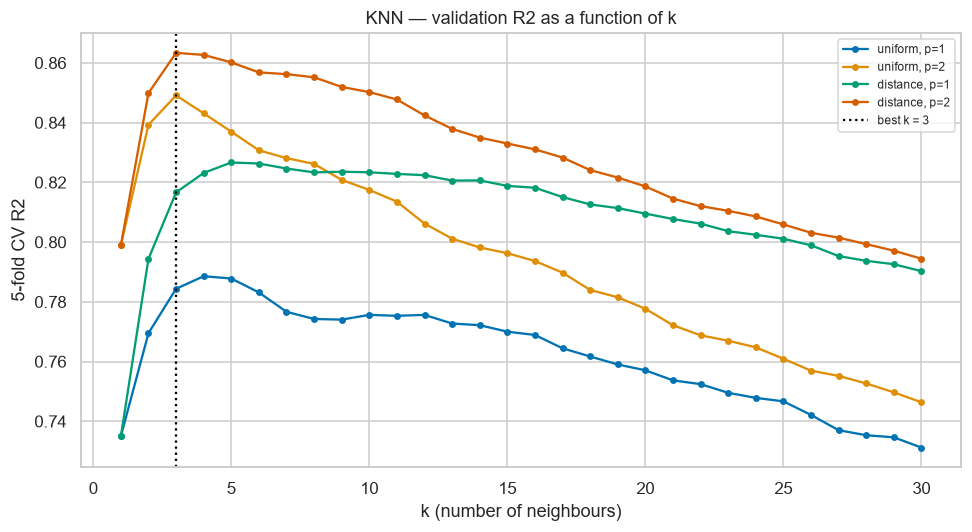

In [44]:
res_knn = pd.DataFrame(knn_gs.cv_results_)

fig, ax = plt.subplots(figsize=(9, 5))
for w in ["uniform", "distance"]:
    for p in [1, 2]:
        sub = res_knn[(res_knn["param_model__weights"] == w) &
                      (res_knn["param_model__p"] == p)].sort_values("param_model__n_neighbors")
        ax.plot(sub["param_model__n_neighbors"].astype(int), sub["mean_test_score"],
                "o-", ms=3.5, label=f"{w}, p={p}")
ax.axvline(knn_gs.best_params_["model__n_neighbors"], ls=":", color="black",
           label=f"best k = {knn_gs.best_params_['model__n_neighbors']}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("5-fold CV R2")
ax.set_title("KNN — validation R2 as a function of k")
ax.legend(fontsize=8)
plt.show()

At `k=1` the model just copies its nearest neighbour: training R² is basically 1 but CV R² only about 0.80. As `k` grows, variance drops until the neighbourhood starts pulling in dissimilar mixes and bias takes over. The best value is small (`k=3`), suggesting strength changes quickly between similar-looking mixes. `weights='distance'` beats `'uniform'` (0.863 vs 0.849 CV R²). The 0.996 training R² isn't meaningful: with distance weighting, every training point is its own nearest neighbour at distance 0.

---
# 15. Results: all ten models on the same test set

One table, ranked by test R². Every model was fitted on the same training split and scored on the same held-out test set.

In [45]:
metric_cols = ["Train R2", "Test R2", "Test RMSE", "Test MAE", "Overfit gap"]

summary = (pd.DataFrame(results).T[metric_cols]
             .astype(float)
             .sort_values("Test R2", ascending=False))
summary.insert(0, "Rank", range(1, len(summary) + 1))

print("Summary of all models (ranked by test R2):")
display(summary.round(4))

print("Configuration selected for each model:")
display(pd.DataFrame(results).T[["Notes"]].loc[summary.index])

Summary of all models (ranked by test R2):


,Rank,Train R2,Test R2,Test RMSE,Test MAE,Overfit gap
8. Gradient Boosting,1,0.9847,0.9257,4.3959,3.0037,0.0590
7. Random Forest,2,0.9851,0.9117,4.7939,3.5343,0.0734
10. K-Nearest Neighbors,3,0.9964,0.8949,5.2287,3.3301,0.1014
9. Support Vector Regressor,4,0.9378,0.8939,5.2533,3.5148,0.0439
5. Polynomial Regression,5,0.9268,0.8712,5.7899,4.2101,0.0556
6. Decision Tree,6,0.9141,0.8424,6.4034,4.8640,0.0717
3. Lasso Regression,7,0.8278,0.8302,6.6462,5.1700,-0.0024
4. ElasticNet Regression,8,0.8278,0.8302,6.6464,5.1699,-0.0024
2. Ridge Regression,9,0.8282,0.8301,6.6488,5.1733,-0.0019
1. Linear Regression,10,0.8283,0.8296,6.6594,5.1824,-0.0012


Configuration selected for each model:


,Notes
8. Gradient Boosting,"learning_rate=0.2, max_depth=2, n_estimators=8..."
7. Random Forest,"max_depth=20, max_features=sqrt, min_samples_l..."
10. K-Nearest Neighbors,"n_neighbors=3, p=2, weights=distance"
9. Support Vector Regressor,"C=50, epsilon=0.5, gamma=0.05, kernel=rbf"
5. Polynomial Regression,"degree=2, LinearRegression on expansion"
6. Decision Tree,"max_depth=10, min_samples_leaf=10, min_samples..."
3. Lasso Regression,alpha=0.01124
4. ElasticNet Regression,"alpha=0.01172, l1_ratio=1.0"
2. Ridge Regression,alpha=0.4075
1. Linear Regression,"OLS, no hyperparameters"


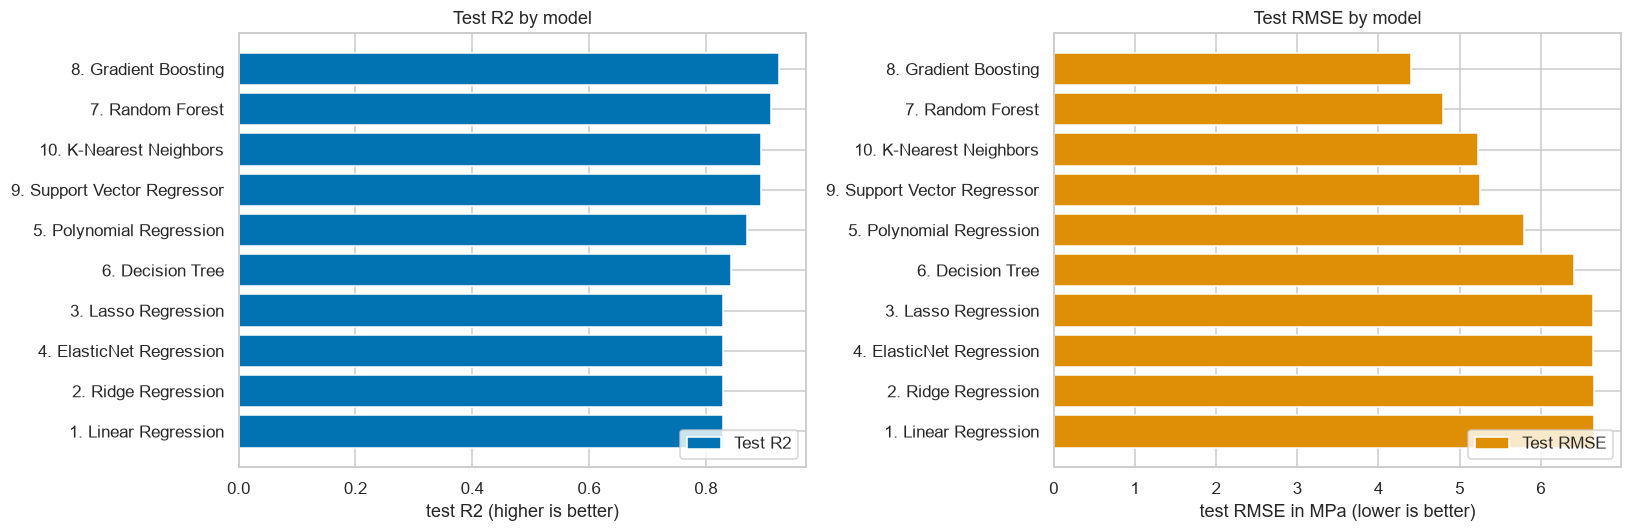

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ordered = summary.iloc[::-1]          # best model at the top of the horizontal bars

axes[0].barh(ordered.index, ordered["Test R2"], label="Test R2")
axes[0].set_xlabel("test R2 (higher is better)")
axes[0].set_title("Test R2 by model")
axes[0].legend(loc="lower right")

axes[1].barh(ordered.index, ordered["Test RMSE"], color=sns.color_palette("colorblind")[1], label="Test RMSE")
axes[1].set_xlabel("test RMSE in MPa (lower is better)")
axes[1].set_title("Test RMSE by model")
axes[1].legend(loc="lower right")

plt.show()

**Observation (results).** 

Ranking:
Gradient Boosting wins clearly, 0.9257 test R², 4.40 MPa RMSE. Random Forest is second (0.9117). Then there's a real gap down to KNN and SVR (~0.89), then Polynomial (0.87), then the single tree (0.84), then the four linear models bunched together right at the bottom (0.8296 to 0.8302).

What that tells us:
The linear models sitting 0.10 R² behind the best model, and Polynomial jumping from 0.83 to 0.87 just by adding degree-2 terms, both point the same way: this relationship isn't linear. If it were, the linear models wouldn't be stuck this far behind.

Overfitting:
Worth flagging that KNN has the biggest overfit gap of the top models (0.101, train R² 0.996 vs test 0.895), so even though it beat SVR on the leaderboard we'd trust it a little less.

---
# 16. Effect of hyperparameter tuning

Nine of ten models were tuned with `GridSearchCV` (Linear Regression has none to tune). To see what tuning bought, each model is also fitted with scikit-learn's **default** settings on the same split and folds. The default Polynomial model uses degree 2, `PolynomialFeatures`' own default.

In [47]:
# name in `results`  ->  (untuned pipeline with default settings, the fitted GridSearchCV object)
tuning_specs = {
    "2. Ridge Regression":         (make_pipe(Ridge(random_state=RANDOM_STATE)),                 ridge_gs),
    "3. Lasso Regression":         (make_pipe(Lasso(random_state=RANDOM_STATE)),                 lasso_gs),
    "4. ElasticNet Regression":    (make_pipe(ElasticNet(random_state=RANDOM_STATE)),            enet_gs),
    "5. Polynomial Regression":    (Pipeline([("prep", clone(preprocessor)),
                                              ("poly", PolynomialFeatures(include_bias=False)),
                                              ("model", LinearRegression())]),                    poly_gs),
    "6. Decision Tree":            (make_pipe(DecisionTreeRegressor(random_state=RANDOM_STATE)), tree_gs),
    "7. Random Forest":            (make_pipe(RandomForestRegressor(random_state=RANDOM_STATE)), rf_gs),
    "8. Gradient Boosting":        (make_pipe(GradientBoostingRegressor(random_state=RANDOM_STATE)), gb_gs),
    "9. Support Vector Regressor": (make_pipe(SVR()),                                            svr_gs),
    "10. K-Nearest Neighbors":     (make_pipe(KNeighborsRegressor()),                            knn_gs),
}

rows = []
for name, (default_pipe, gs) in tuning_specs.items():
    default_cv   = cross_val_score(default_pipe, X_train, y_train, cv=CV, scoring="r2", n_jobs=4).mean()
    default_test = r2_score(y_test, clone(default_pipe).fit(X_train, y_train).predict(X_test))
    tuned_test   = results[name]["Test R2"]
    rows.append({
        "Model":           name,
        "Default CV R2":   default_cv,
        "Tuned CV R2":     gs.best_score_,
        "CV gain":         gs.best_score_ - default_cv,
        "Default Test R2": default_test,
        "Tuned Test R2":   tuned_test,
        "Test gain":       tuned_test - default_test,
        "Best parameters": ", ".join(f"{k.split('__')[-1]}={v}" for k, v in gs.best_params_.items()),
    })

tuning_df = pd.DataFrame(rows).set_index("Model").sort_values("CV gain", ascending=False)
display(tuning_df.round(4))

,Default CV R2,Tuned CV R2,CV gain,Default Test R2,Tuned Test R2,Test gain,Best parameters
Model,,,,,,,
9. Support Vector Regressor,0.7517,0.8979,0.1463,0.7835,0.8939,0.1104,"C=50, epsilon=0.5, gamma=0.05, kernel=rbf"
4. ElasticNet Regression,0.7301,0.8196,0.0896,0.7435,0.8302,0.0867,"alpha=0.011721022975334805, l1_ratio=1.0"
3. Lasso Regression,0.7794,0.8197,0.0402,0.7927,0.8302,0.0375,alpha=0.011242100350620862
6. Decision Tree,0.7895,0.8182,0.0287,0.8389,0.8424,0.0036,"max_depth=10, min_samples_leaf=10, min_samples..."
10. K-Nearest Neighbors,0.8370,0.8633,0.0264,0.8396,0.8949,0.0553,"n_neighbors=3, p=2, weights=distance"
8. Gradient Boosting,0.8968,0.9190,0.0222,0.9042,0.9257,0.0215,"learning_rate=0.2, max_depth=2, n_estimators=8..."
7. Random Forest,0.8890,0.8984,0.0094,0.9124,0.9117,-0.0007,"max_depth=20, max_features=sqrt, min_samples_l..."
2. Ridge Regression,0.8191,0.8192,0.0001,0.8300,0.8301,0.0001,alpha=0.4075392965871778
5. Polynomial Regression,0.8390,0.8390,0.0000,0.8712,0.8712,0.0000,degree=2


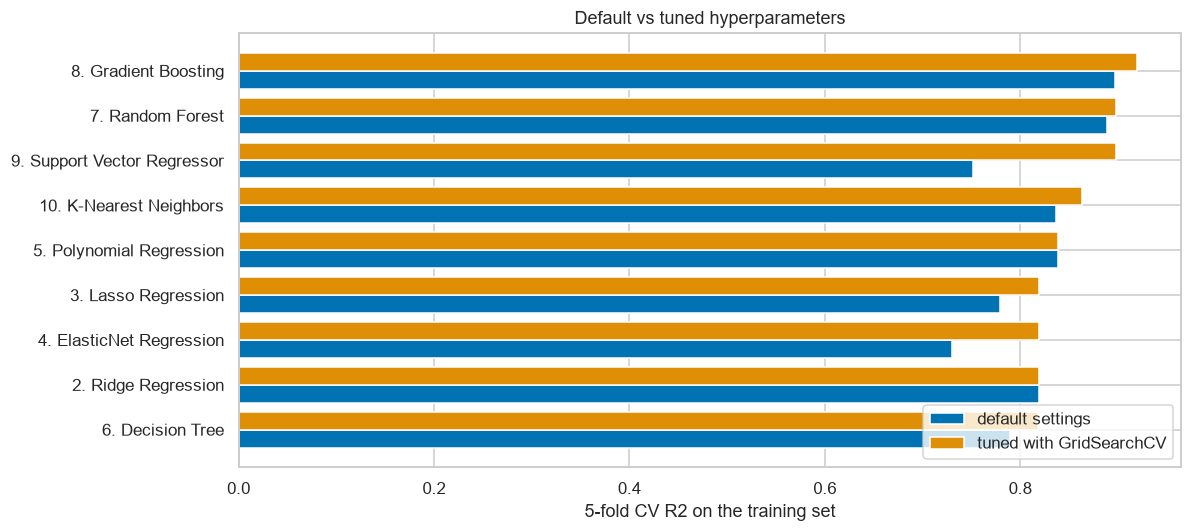

In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = tuning_df.sort_values("Tuned CV R2")
pos = np.arange(len(plot_df))

ax.barh(pos - 0.2, plot_df["Default CV R2"], height=0.4, label="default settings")
ax.barh(pos + 0.2, plot_df["Tuned CV R2"],   height=0.4, label="tuned with GridSearchCV")
ax.set_yticks(pos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("5-fold CV R2 on the training set")
ax.set_title("Default vs tuned hyperparameters")
ax.legend(loc="lower right")
plt.show()

**Observation (tuning).** TODO: write 4-5 sentences in your own words.

- Big gains:
SVR improved the most by a wide margin, CV R² went from 0.752 to 0.898 (+0.146), test R² from 0.784 to 0.894. The default C=1 is just too small for this data and underfits, tuning found C=50 which lets it actually fit. ElasticNet (+0.090 CV) and Lasso (+0.040 CV) also improved a decent amount, and both gains show up on the test set too (+0.087 and +0.038), so we don't think it's just tuning to the CV folds.

- Basically nothing:
Ridge moved by 0.0001 and Polynomial by 0.0000, since Ridge's tuned alpha landed close to sklearn's default anyway and Polynomial's best degree (2) is what PolynomialFeatures defaults to.

- Grid edges:
Worth noting for Gradient Boosting (section 12) that both learning_rate and n_estimators landed at the edge of their grids, so we might be underselling how much that model could still improve with more tuning room.

---
# 17. 5-fold cross-validated R² for the two best models

A single split can get lucky or unlucky, so the two best models (by test R² in section 15) also get scored with 5-fold cross-validation on the training set. The spread across folds shows how stable each score is.

One caveat: the same folds were used to tune the hyperparameters, so the CV score runs a bit optimistic. The held-out test R² from section 15 is the fairer number.

,fold 1,fold 2,fold 3,fold 4,fold 5,CV mean,CV std,Test R2
8. Gradient Boosting,0.9245,0.9034,0.9183,0.9258,0.9231,0.9190,0.0082,0.9257
7. Random Forest,0.8924,0.8922,0.8873,0.9164,0.9039,0.8984,0.0105,0.9117


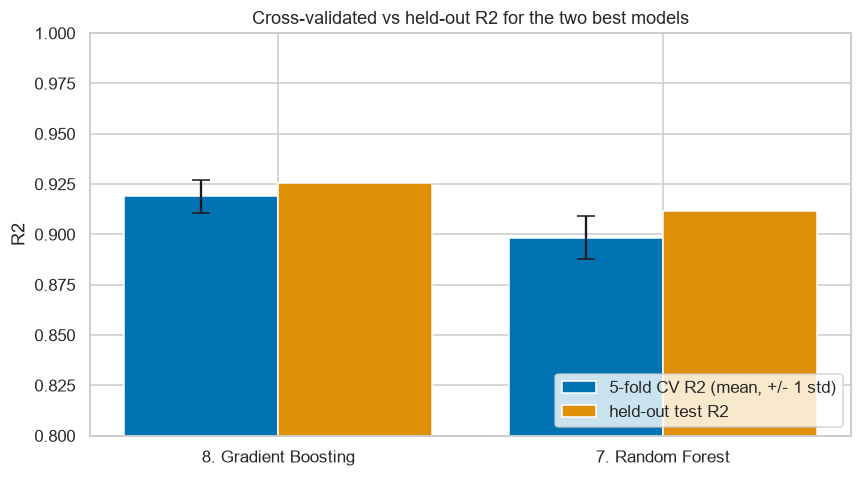

In [49]:
top2 = summary.index[:2].tolist()

cv_table = {}
for name in top2:
    scores = cross_val_score(fitted[name], X_train, y_train, cv=CV, scoring="r2", n_jobs=4)
    row = {f"fold {i + 1}": s for i, s in enumerate(scores)}
    row["CV mean"] = scores.mean()
    row["CV std"]  = scores.std()
    row["Test R2"] = results[name]["Test R2"]
    cv_table[name] = row

cv_df = pd.DataFrame(cv_table).T
display(cv_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(len(top2))
ax.bar(xs - 0.2, cv_df["CV mean"], width=0.4, yerr=cv_df["CV std"], capsize=6, label="5-fold CV R2 (mean, +/- 1 std)")
ax.bar(xs + 0.2, cv_df["Test R2"], width=0.4, label="held-out test R2")
ax.set_xticks(xs)
ax.set_xticklabels(top2)
ax.set_ylabel("R2")
ax.set_ylim(0.8, 1.0)
ax.set_title("Cross-validated vs held-out R2 for the two best models")
ax.legend(loc="lower right")
plt.show()

**Observation (cross-validation).** 
Gradient Boosting's folds run 0.9034 to 0.9258, mean 0.9190, std 0.0082, tight. Random Forest is 0.8984 mean, std 0.0105, a bit looser but still not bad. Both CV means come in a little under their test R² (0.9257 and 0.9117), which fits the intro text above, these are the same folds that picked the hyperparameters, so CV runs a bit optimistic and the test number is the one to trust. The gap between the two models (about 0.02) is roughly twice either model's std, so we think Gradient Boosting is genuinely ahead and not just a lucky split, though it's not a massive margin either.

---
# 18. Diagnostics for the best model

Predicted vs actual strength, and the residuals (actual minus predicted), on the held-out test set.

Best model: 8. Gradient Boosting
Test R2 = 0.9257   RMSE = 4.396 MPa   MAE = 3.004 MPa
Mean residual = -0.085 MPa (close to 0 means no systematic over/under-prediction)


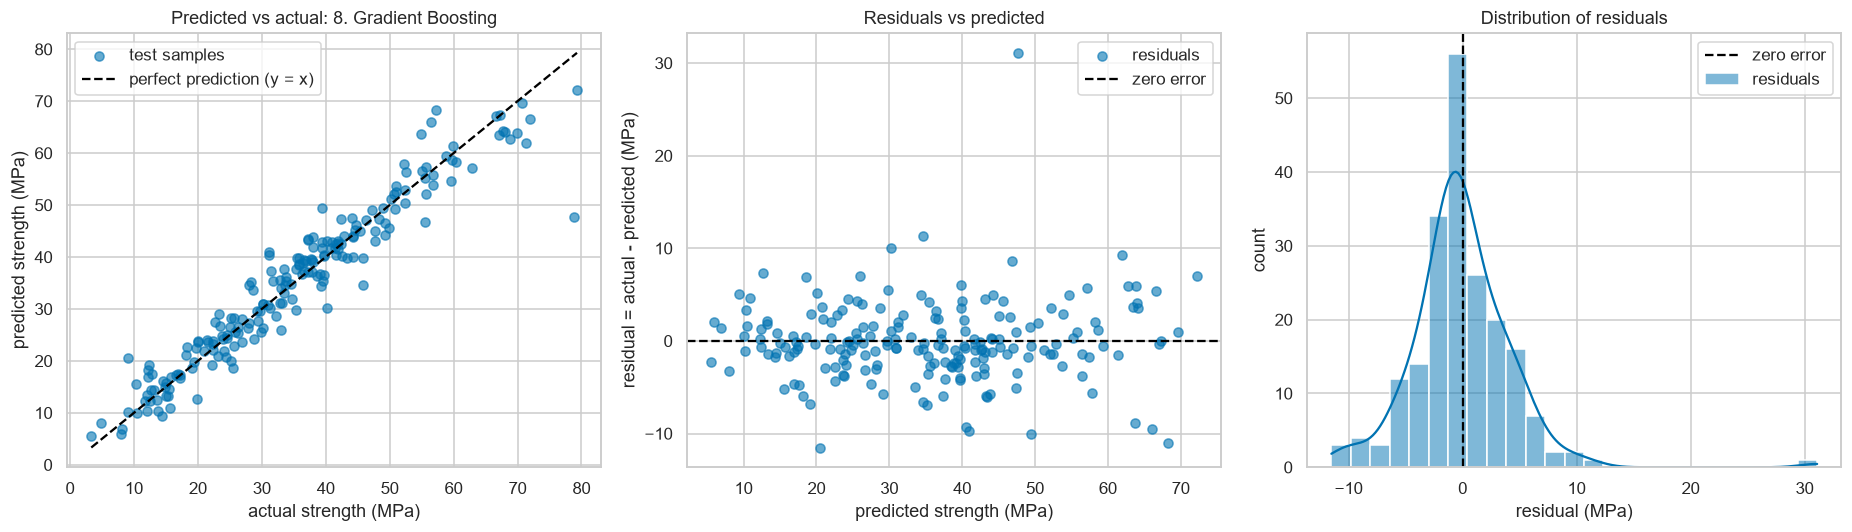

In [50]:
best_name  = summary.index[0]
best_model = fitted[best_name]

pred  = best_model.predict(X_test)
resid = y_test - pred
print(f"Best model: {best_name}")
print(f"Test R2 = {r2_score(y_test, pred):.4f}   RMSE = {root_mean_squared_error(y_test, pred):.3f} MPa   "
      f"MAE = {mean_absolute_error(y_test, pred):.3f} MPa")
print(f"Mean residual = {resid.mean():.3f} MPa (close to 0 means no systematic over/under-prediction)")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1) predicted vs actual
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].scatter(y_test, pred, alpha=.6, label="test samples")
axes[0].plot(lims, lims, "--", color="black", label="perfect prediction (y = x)")
axes[0].set_xlabel("actual strength (MPa)")
axes[0].set_ylabel("predicted strength (MPa)")
axes[0].set_title(f"Predicted vs actual: {best_name}")
axes[0].legend()

# 2) residuals vs predicted
axes[1].scatter(pred, resid, alpha=.6, label="residuals")
axes[1].axhline(0, ls="--", color="black", label="zero error")
axes[1].set_xlabel("predicted strength (MPa)")
axes[1].set_ylabel("residual = actual - predicted (MPa)")
axes[1].set_title("Residuals vs predicted")
axes[1].legend()

# 3) distribution of residuals
sns.histplot(resid, bins=25, kde=True, ax=axes[2], label="residuals")
axes[2].axvline(0, ls="--", color="black", label="zero error")
axes[2].set_xlabel("residual (MPa)")
axes[2].set_ylabel("count")
axes[2].set_title("Distribution of residuals")
axes[2].legend()

plt.show()

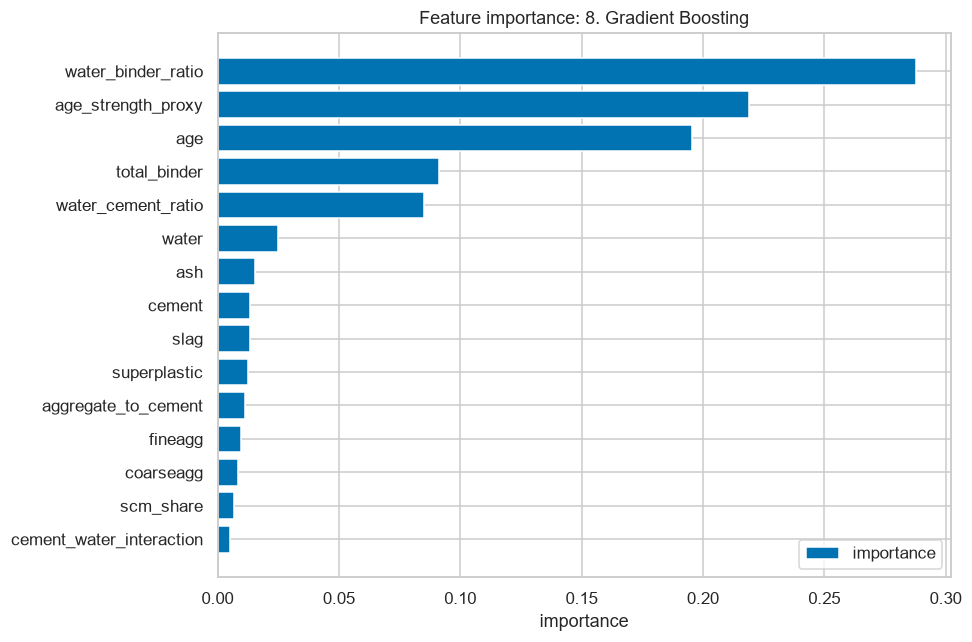

water_binder_ratio          0.2877
age_strength_proxy          0.2188
age                         0.1954
total_binder                0.0911
water_cement_ratio          0.0851
water                       0.0251
ash                         0.0156
cement                      0.0136
slag                        0.0135
superplastic                0.0124
aggregate_to_cement         0.0112
fineagg                     0.0098
coarseagg                   0.0085
scm_share                   0.0068
cement_water_interaction    0.0053


In [51]:
# Feature importance of the best model, if it is tree-based (Decision Tree, Random Forest, Gradient Boosting).
best_est = best_model.named_steps["model"]
if hasattr(best_est, "feature_importances_"):
    best_imp = pd.Series(best_est.feature_importances_, index=FEATURE_NAMES).sort_values()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(best_imp.index, best_imp.values, label="importance")
    ax.set_xlabel("importance")
    ax.set_title(f"Feature importance: {best_name}")
    ax.legend(loc="lower right")
    plt.show()
    print(best_imp.sort_values(ascending=False).round(4).to_string())
else:
    print(f"{best_name} has no feature_importances_ (not a tree-based model).")

**Observation (diagnostics).** 

- Predicted vs actual:
Points sit close to the y=x line for most of the range, a bit more scattered up at the high-strength end, probably just fewer training samples up there.

- Residuals:
No real funnel shape, so the error isn't obviously growing with strength, and nothing curved that would suggest the model is missing structure. Mean residual is -0.085 MPa, basically zero, and the histogram looks centred and roughly symmetric, so no bias in either direction.

- What it's using:
water_binder_ratio (0.29) and the two age features together (0.41) account for most of the importance, which lines up with what the single tree and Random Forest both found too (sections 6 and 7), so it's not just this one model latching onto something odd.

---
# 19. Impact of feature scaling on KNN and SVR

KNN and SVR (RBF kernel) both depend on distances between samples, so one feature with a huge numeric range can dominate every distance. To check that, the tuned KNN and SVR get refitted with the same hyperparameters but **without** `StandardScaler`. A Random Forest is included as a control, since trees only compare values within one column, so scaling shouldn't affect it at all.

,Test R2 with scaling,Test R2 without scaling,Test RMSE with scaling,Test RMSE without scaling,R2 lost without scaling
Model,,,,,
KNN,0.8949,0.4814,5.2287,11.6163,0.4135
SVR,0.8939,0.5907,5.2533,10.3195,0.3032
Random Forest (control),0.9117,0.9115,4.7939,4.7976,0.0001


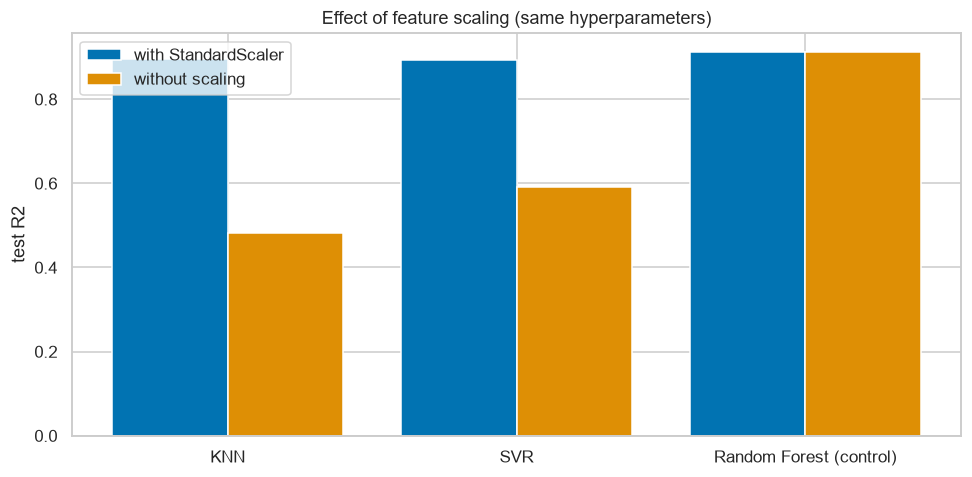

In [52]:
def unscaled_pipe(model):
    """Same recipe as make_pipe, but WITHOUT the StandardScaler (only imputer + log1p(age))."""
    return Pipeline([("columns", clone(column_transformer)), ("model", model)])


def tuned_params(gs):
    """'model__C' -> 'C' so the tuned settings can be passed straight to a fresh estimator."""
    return {k.split("__")[-1]: v for k, v in gs.best_params_.items()}


scaling_rows = []
for label, make_model in [
    ("KNN",                       lambda: KNeighborsRegressor(**tuned_params(knn_gs))),
    ("SVR",                       lambda: SVR(**tuned_params(svr_gs))),
    ("Random Forest (control)",   lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=4, **tuned_params(rf_gs))),
]:
    scaled   = make_pipe(make_model()).fit(X_train, y_train)
    unscaled = unscaled_pipe(make_model()).fit(X_train, y_train)
    scaling_rows.append({
        "Model": label,
        "Test R2 with scaling":     r2_score(y_test, scaled.predict(X_test)),
        "Test R2 without scaling":  r2_score(y_test, unscaled.predict(X_test)),
        "Test RMSE with scaling":   root_mean_squared_error(y_test, scaled.predict(X_test)),
        "Test RMSE without scaling": root_mean_squared_error(y_test, unscaled.predict(X_test)),
    })

scaling_df = pd.DataFrame(scaling_rows).set_index("Model")
scaling_df["R2 lost without scaling"] = scaling_df["Test R2 with scaling"] - scaling_df["Test R2 without scaling"]
display(scaling_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
xs = np.arange(len(scaling_df))
ax.bar(xs - 0.2, scaling_df["Test R2 with scaling"],    width=0.4, label="with StandardScaler")
ax.bar(xs + 0.2, scaling_df["Test R2 without scaling"], width=0.4, label="without scaling")
ax.set_xticks(xs)
ax.set_xticklabels(scaling_df.index)
ax.set_ylabel("test R2")
ax.set_title("Effect of feature scaling (same hyperparameters)")
ax.legend()
plt.show()

In [53]:
# Why: without scaling, the feature with the largest spread dominates every distance.
raw = X_train.copy()
raw["age"] = np.log1p(raw["age"])          # the unscaled pipeline still applies log1p to age
var_share = (raw.var() / raw.var().sum() * 100).sort_values(ascending=False)
print("Share of the total variance carried by each UNSCALED feature (%):")
print(var_share.round(3).to_string())

Share of the total variance carried by each UNSCALED feature (%):
cement_water_interaction    99.989
cement                       0.003
total_binder                 0.002
slag                         0.002
fineagg                      0.002
coarseagg                    0.002
ash                          0.001
water                        0.000
superplastic                 0.000
age_strength_proxy           0.000
aggregate_to_cement          0.000
age                          0.000
water_cement_ratio           0.000
scm_share                    0.000
water_binder_ratio           0.000


**Observation (scaling).** 
KNN drops from 0.895 to 0.481 without scaling, SVR from 0.894 to 0.591. Random Forest barely moves at all (0.9117 to 0.9115, basically noise). The reason is right there in the variance table: unscaled, cement_water_interaction alone accounts for 99.99% of the total variance across all 15 features, because it's a product of two columns and ends up with a way bigger raw range than everything else. KNN and SVR both work off distance across all the features at once, so that one column ends up deciding almost every distance calculation by itself. Trees don't have this problem because a split only ever checks one column against a threshold, so the scale of the other columns is irrelevant.

---
# 20. Conclusion

In [54]:
# Facts pulled straight from the results above, to support the written conclusion.
lin_r2   = results["1. Linear Regression"]["Test R2"]
best_r2  = summary.iloc[0]["Test R2"]
worst_gap = summary["Overfit gap"].idxmax()

print(f"Best model             : {summary.index[0]}  (test R2 = {best_r2:.4f}, RMSE = {summary.iloc[0]['Test RMSE']:.2f} MPa)")
print(f"Second best            : {summary.index[1]}  (test R2 = {summary.iloc[1]['Test R2']:.4f})")
print(f"Linear baseline        : test R2 = {lin_r2:.4f}")
print(f"Gain over the baseline : {best_r2 - lin_r2:+.4f} R2")
print(f"Largest overfit gap    : {worst_gap}  (train R2 - test R2 = {summary.loc[worst_gap, 'Overfit gap']:.4f})")
print(f"Tuning gain (CV R2)    : largest for {tuning_df['CV gain'].idxmax()} ({tuning_df['CV gain'].max():+.4f})")

Best model             : 8. Gradient Boosting  (test R2 = 0.9257, RMSE = 4.40 MPa)
Second best            : 7. Random Forest  (test R2 = 0.9117)
Linear baseline        : test R2 = 0.8296
Gain over the baseline : +0.0962 R2
Largest overfit gap    : 10. K-Nearest Neighbors  (train R2 - test R2 = 0.1014)
Tuning gain (CV R2)    : largest for 9. Support Vector Regressor (+0.1463)


**Conclusion.** 

**Result**:
Gradient Boosting came out on top: 0.9257 test R², 4.40 MPa RMSE, 3.00 MPa MAE, about 0.10 R² and 2.3 MPa ahead of plain Linear Regression.

**Why**:
We think the gap comes down to the relationship being non-linear. The EDA never turned up a feature with more than about 0.6 correlation to strength on its own, the linear models' coefficients were tangled up with multicollinearity, and Polynomial jumping from 0.83 to 0.87 just by adding degree-2 terms is close to direct proof of curvature and interactions in the data.

**Tuning**:
Tuning mattered most for SVR and ElasticNet, both had default settings that were clearly wrong for this data (SVR's C=1 underfits badly), while Ridge and Polynomial barely moved since their defaults were already close to what the search found anyway.

**Reliability**:
The cross-validation numbers were reassuring, tight fold spread for both top models and CV means close to their test scores, though we're keeping in mind the CV folds were also used for tuning so the real number is the held-out test score. The diagnostics didn't turn up any obvious pattern in the errors either.

**Limitations**:
About 1000 rows from one dataset isn't a lot, a couple of the grids (Gradient Boosting's learning_rate and n_estimators) landed right at their edges which makes us wonder if there's more headroom, and the feature importances get split unevenly across correlated columns so they're more of a rough guide than an exact ranking.

**Next step**:
With more time we'd widen the Gradient Boosting grid past where it currently maxes out and see if it keeps improving or actually plateaus.